In [ ]:
!pip install pingouin
!pip install scipy
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

#1.EDA - 전체 데이터의 흐름을 통한 인사이트 발견

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import datetime as dt
import seaborn as sns
import numpy as np
from mlxtend.frequent_patterns import association_rules, apriori
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import math

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False
pd.set_option('display.max_columns',None)
pd.set_option('display.max_row',None)
import matplotlib.pyplot as plt

### **1-0) 데이터 불러오기**

In [ ]:
df_on = pd.read_csv('/content/drive/MyDrive/유나다 코드 정리/이커머스/Onlinesales_info.csv')
df_cus = pd.read_csv('/content/drive/MyDrive/유나다 코드 정리/이커머스/Customer_info.csv')
df_dis = pd.read_csv('/content/drive/MyDrive/유나다 코드 정리/이커머스/Discount_info.csv')
df_mar = pd.read_csv('/content/drive/MyDrive/유나다 코드 정리/이커머스/Marketing_info.csv')
df_tax = pd.read_csv('/content/drive/MyDrive/유나다 코드 정리/이커머스/Tax_info.csv')
df_on['거래날짜'] = pd.to_datetime(df_on['거래날짜'])

### **1-1) eda에 사용할 지표 만들기**

##### 고객생애가치 (CLV)

> EDA 및 분석을 하는 과정에 있어서 유효한 지표를 통해 데이터를 해석하는 것이 더 설득력 있다고 판단했기 때문에, 우리는 고객이 기업에 어느 정도의 가치를 가져올 수 있는지 나타내는 고객 생애 가치(CLV)를 지표로 채택 하여 사용하였다.

CLV는 계산 방법은 아래와 같다.

* 고객 가치 = 평균 구매 가치 × 평균 구매 빈도
  * 평균 구매 가치 = 특정 기간 내 총 수익 / 특정 기간 내 총 구매 횟수
* **CLV = 고객 가치 × 고객 평균 유지 기간**\
(여기서, 고객 평균 유지 기간은 `Online Sales_info`의 `가입기간`을 활용하여 산출.)



In [ ]:
clv = df_on.groupby('고객ID').agg({'평균금액': 'sum', '고객ID': 'count'}).rename(columns={'평균금액': '총구매금액', '고객ID': '구매횟수'})
clv['평균구매금액'] = clv['총구매금액'] / clv['구매횟수']
# 2019년 1년간의 구매데이터이기 때문에 평균구매빈도를 구하기 위해서 구매횟수에서 일수를 나눠주기
clv['평균구매빈도'] = clv['구매횟수']/365
clv = pd.merge(df_cus, clv, on='고객ID', how='outer')
#가입기간을 년 단위로 바꿔주기
clv['가입기간'] = clv['가입기간']/12

#고객ID별로 고객생애가치 컬럼 추가
clv['고객생애가치'] = clv['가입기간']*clv['평균구매금액']*clv['평균구매빈도']
clv.head(3)

,고객ID,성별,고객지역,가입기간,총구매금액,구매횟수,평균구매금액,평균구매빈도,고객생애가치
0,USER_1358,남,Chicago,1.000000,20483.98,297,68.969630,0.813699,56.120493
1,USER_0190,남,California,3.583333,2320.33,44,52.734773,0.120548,22.779495
2,USER_0066,남,Chicago,2.750000,1319.79,42,31.423571,0.115068,9.943623


In [ ]:
# Onlinesales_info.csv에 고객생애가치를 위한 파생변수 추가
df_on = pd.merge(df_on, clv[['고객ID','고객생애가치']], on='고객ID', how='outer')
df_on.head(3)

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,고객생애가치
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,56.120493
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,56.120493
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,56.120493


##### retention

##### arppu

### **1-2) Onlinesales_info**

**파생변수 : 다음에 구매한 날짜,다음에 사용한 쿠폰**

* 재구매까지 걸리는 시간과 재구매시의 쿠폰상태를 확인해보기 위해 추가로 `다음구매날짜`, `다음쿠폰상태`, `재구매날까지의일` 파생변수를 추가하였다.\
(당일에 결제한 이력에 대해서는 재구매로 계산 하지않고, 최소 하루 뒤에 구매한 이력부터 재구매로 계산하였다. -> 해당 행 뒤에 당일에 구매한 행이 있으면 재구매날까지의일을 0으로 지정하고 해당 행 뒤에 다른 날에 구매한 행이 있을 때 재구매날까지의 일을 계산하여 값을 지정)

In [ ]:
users = list(df_on['고객ID'].unique())
df_on['다음구매날짜'] = df_on['거래날짜']
df_on['다음구매날짜'] = pd.to_datetime(df_on['다음구매날짜'])
df_on['다음쿠폰상태'] = df_on['쿠폰상태']
for user in users:
    users_index = df_on[df_on['고객ID'] == user].index
    for idx in range(len(users_index)):
        if len(users_index) <= 1:
            df_on.loc[users_index[idx],'다음구매날짜'] = 0
            df_on.loc[users_index[idx],'다음쿠폰상태'] = 0
        else:
            if idx == 0:
                continue
            else:
                df_on.loc[users_index[idx-1],'다음구매날짜'] = df_on.loc[users_index[idx],'거래날짜']
                df_on.loc[users_index[idx-1],'다음쿠폰상태'] = df_on.loc[users_index[idx],'쿠폰상태']

df_on['최종금액'] = df_on['수량']*df_on['평균금액']
df_on['거래날짜'] = pd.to_datetime(df_on['거래날짜'])
df_on['다음구매날짜'] = df_on['다음구매날짜'].replace(0, pd.NaT)
df_on['다음구매날짜'] = pd.to_datetime(df_on['다음구매날짜'])
df_on['재구매날까지의일']  = df_on['다음구매날짜']-df_on['거래날짜']
df_on['재구매날까지의일'] = df_on['재구매날까지의일'].apply(lambda x: x.days)
df_on.head(3)

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,고객생애가치,다음구매날짜,다음쿠폰상태,최종금액,재구매날까지의일
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,56.120493,2019-01-01,Used,153.71,0.0
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,56.120493,2019-01-01,Used,153.71,0.0
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,56.120493,2019-01-01,Not Used,2.05,0.0



#####쿠폰을 사용했을 때 리텐션이 오르는 카테고리가 있고, 되려 떨어지는 카테고리가 있다._유진이 (Onlinesales_info)

#####상위 군집일수록 인기제품 (제품자체의 누적판매량,누적판매금액이 높은)을 구매했을 것이다./카테고리별 제품ID별 인기 편향_유진이 (Onlinesales_info)

### 1-3) **Customer_info**

##### 업셀링 : 30%대에 사는 고객 , 여성, 시카고 , 요일별 구매 (6-1 코드)_ 유진이 (Customer_info)

### 1-4) **Marketing_info**


>마케팅 데이터를 분석하기에 앞서 우리는 아래와 같은 가정을 전제로 한 후 분석을 진행하였다.

* **마케팅을 진행한 날짜부터 14일까지의 구매이력이 모두 광고 영향을 어느정도 받았다고 가정하였으며, 마찬가지로 마케팅을 진행한 날짜부터 14일이 지난 후의 구매데이터는 해당 마케팅과 연관이 없다고 가정하였다.**\
(광고일부터 14일내의 구매한 이력을 광고의 성과로 집계하게 된 이유는 `에이블리`의 광고성과기준을 참고하였다.)

In [ ]:
# 광고일부터 14일까지의 구매데이터, CLV를 모두 더해서 날짜별로 새로운 데이터프레임 만들기
df_mar2 = df_mar.copy()
df_mar2['거래날짜'] = df_mar2['날짜']
df_mar2['거래날짜'] = pd.to_datetime(df_mar2['거래날짜'])
df_mar_on = pd.merge(df_on, df_mar2, on='거래날짜', how='outer')

df_mar_on['날짜'] = pd.to_datetime(df_mar_on['날짜'])
df_mar_on['거래날짜'] = pd.to_datetime(df_mar_on['거래날짜'])

df_mar_on['2주뒤_날짜'] = df_mar_on['날짜'] + pd.DateOffset(weeks=2)
df_mar_on['총마케팅비용'] = df_mar_on['오프라인비용']+df_mar_on['온라인비용']
selected_rows = df_mar_on[df_mar_on['거래날짜'].between(df_mar_on['날짜'], df_mar_on['2주뒤_날짜'])]

new_df = selected_rows.groupby('날짜').agg({
    '평균금액': 'sum',
    '고객ID': 'count',
}).reset_index().rename(columns={'평균금액': '매출합', '고객ID': '고객수'})

new_df = pd.merge(new_df, df_mar_on[['날짜','오프라인비용', '온라인비용', '총마케팅비용']], on='날짜', how='outer')

week_df = new_df.drop_duplicates()
week_df['ARPPU'] = week_df['매출합']/week_df['고객수']
week_df.head(3)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-23-de14177ee704>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  week_df['ARPPU'] = week_df['매출합']/week_df['고객수']


,날짜,매출합,고객수,오프라인비용,온라인비용,총마케팅비용,ARPPU
0,2019-01-01,5183.16,89,4500,2424.50,6924.50,58.237753
89,2019-01-02,8990.64,115,4500,3480.36,7980.36,78.179478
204,2019-01-03,15428.67,207,4500,1576.38,6076.38,74.534638


##### 1-4-1) 마케팅 비용이 증가할 때 ARPPU의 변화

* 마케팅 비용이 증가할 때 ARPPU또한 함께 증가한다면 매출 증대를 위해서 마케팅 비용을 높히는 것을 하나의 전략으로 세워볼 수 있기 때문에 마케팅 비용과 ARPPU와의 관계를 확인해보았다.


* 총마케팅 비용의 경우 unique 값의 개수가 많았기 때문에 회귀선을 통해 ARPPU와의 관계를 확인해보았다.
* 회귀선을 통해 확인해본 결과 마케팅 비용이 증가할수록 ARPPU의 증가가 뚜렷하게 보였기 때문에 **매출증대를 위해 마케팅 비용을 높히는 전략이 효과가 있을거**라 판단하였다.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated

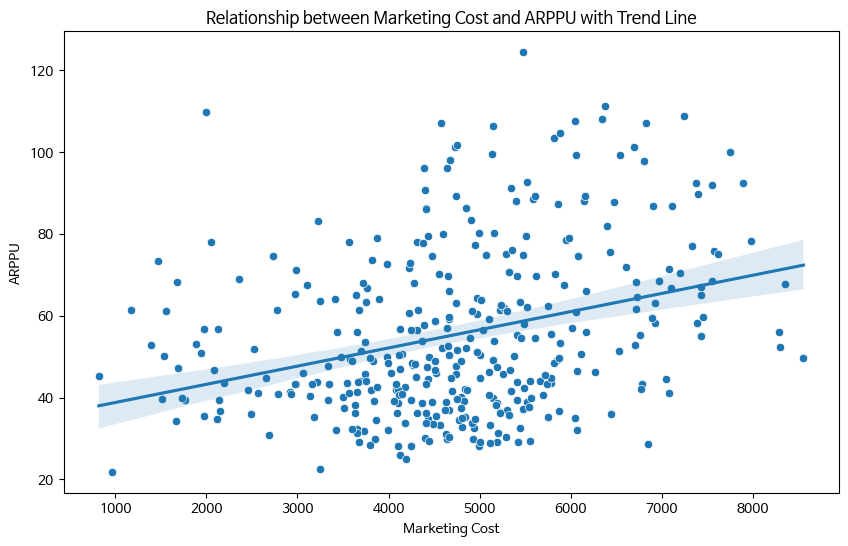

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=week_df, x='총마케팅비용', y='ARPPU')

# 회귀선 추가
sns.regplot(data=week_df, x='총마케팅비용', y='ARPPU', scatter=False)

plt.title('Relationship between Marketing Cost and ARPPU with Trend Line')
plt.xlabel('Marketing Cost')
plt.ylabel('ARPPU')
plt.show()

1-4-2) 오프라인 비용이 증가할 때 ARPPU의 변화

* 오프라인 마케팅 비용이 가장 높은 5000을 제외한 나머지 금액에서 마케팅 비용이 증가할 수록 ARPPU가 함께 증가하는 경향을 보였다.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated NumPy 1.25)
  common = np.find_common_type([values.dtype, comps_array.dtype], [])
/usr/local/lib/python3.10/dist-packages/pandas/core/algorithms.py:522: DeprecationWarning: np.find_common_type is deprecated.  Please use `np.result_type` or `np.promote_types`.
See https://numpy.org/devdocs/release/1.25.0-notes.html and the docs for more information.  (Deprecated

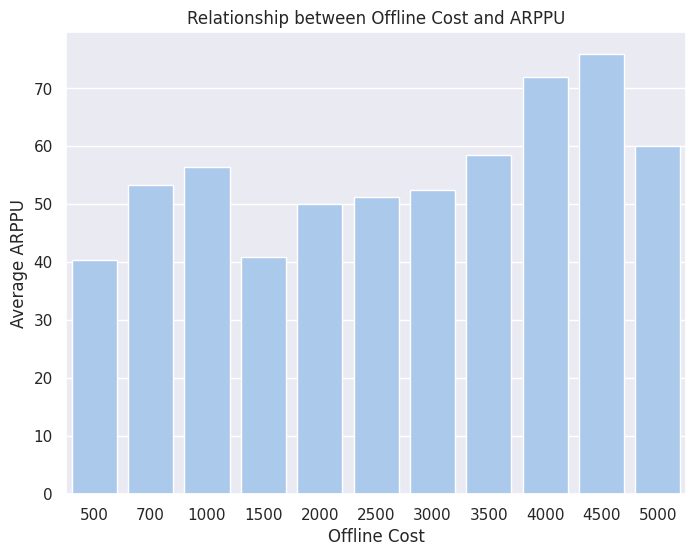

In [ ]:
average_arppu_by_offline_cost = week_df.groupby('오프라인비용')['ARPPU'].mean().reset_index()

sns.set(style="darkgrid")
sns.set_palette("pastel")

plt.figure(figsize=(8, 6))
sns.barplot(x='오프라인비용', y='ARPPU', data=average_arppu_by_offline_cost)
plt.title('Relationship between Offline Cost and ARPPU')
plt.xlabel('Offline Cost')
plt.ylabel('Average ARPPU')
plt.show()

1-4-3) 온라인 비용이 증가할 때 ARPPU의 변화
* 온라인 마케팅 비용의 경우 unique 값의 개수가 많았기 때문에 회귀선을 통해 ARPPU와의 관계를 확인해보았고, 오프라인과 마찬가지로 온라인 마케팅 비용이 증가할 때 ARPPU가 증가하는 경향을 보였다.
* 추가적으로 온라인 마케팅과 오프라인 마케팅 중 ARPPU를 올리기 위해 더 효율적인 마케팅이 무엇인지 알아보기 위해 온/오프라인 마케팅과 ARPPU와의 회귀선을 구한 후 기울기를 비교해보았다.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Online Regression Slope: 42.79474747474745


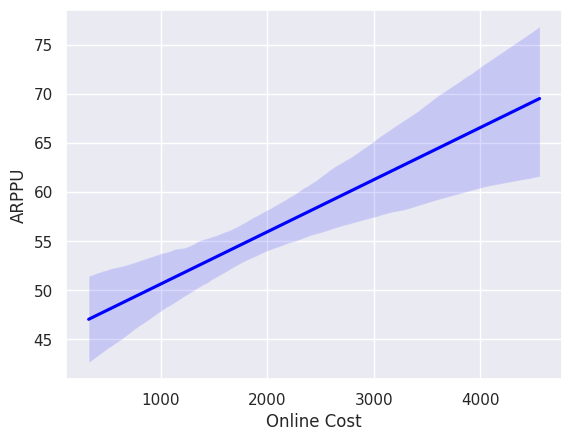

In [ ]:
# 온라인 광고 비용 회귀선 기울기
slope_online, intercept_online = sns.regplot(data=week_df, x='온라인비용', y='ARPPU', scatter=False, color='blue').get_lines()[0].get_data()
plt.xlabel('Online Cost')
print("Online Regression Slope:", slope_online[1] - slope_online[0])

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Offline Regression Slope: 45.454545454545496


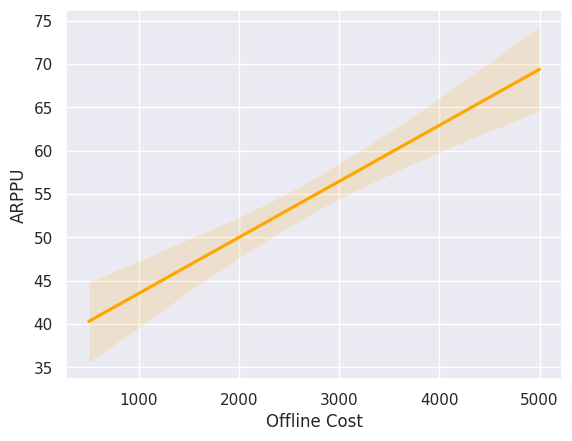

In [ ]:
# 오프라인 광고 비용 회귀선 기울기
slope_offline, intercept_offline = sns.regplot(data=week_df, x='오프라인비용', y='ARPPU', scatter=False, color='orange').get_lines()[0].get_data()
plt.xlabel('Offline Cost')
print("Offline Regression Slope:", slope_offline[1] - slope_offline[0])

* Online Regression Slope: 42.79474747474745
* Offline Regression Slope: 45.454545454545496
* 회귀선의 기울기를 비교해 본 결과 오프라인 광고 비용 회귀선의 기울기가 조금 더 높았으며, 크게 두드러지는 차이는 아니지만 **오프라인 광고 비용을 높혔을 때 ARPPU가 더 많이 오르기 때문에 매출증대를 위한 효과가 좋다고 볼 수 있다**.

##### 1-4-4) 마케팅 비용이 높은 기간에 물건을 구매한 고객의 리텐션과 마케팅 비용이 낮을 때 물건을 구매한 고객의 리텐션 비교


* 마케팅 비용이 높을 때 구매한 고객의 리텐션이 높다면, 고객의 재구매율을 높히기 위해서 마케팅 비용을 높히는 전략을 세워볼 수 있기 때문에 마케팅 비용이 높을 때와 낮을 때 구매한 고객으로 나누어서 리텐션을 확인해보았다.


1-4-4-1)  마케팅 비용이 높을 때`
>마케팅 비용이 상위 25%에 해당할 때 구매한 고객의 리텐션 확인

* 시간이 지날수록 리텐션율이 증가한다.
  * 마지막 달에는 리텐션율이 10%에 가까워지거나 더 높아지는 경향이 있다.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-28-682034834438>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar_top['거래날짜달기준'] = mar_top['거래날짜'].apply(get_month)
<ipython-input-28-682034834438>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

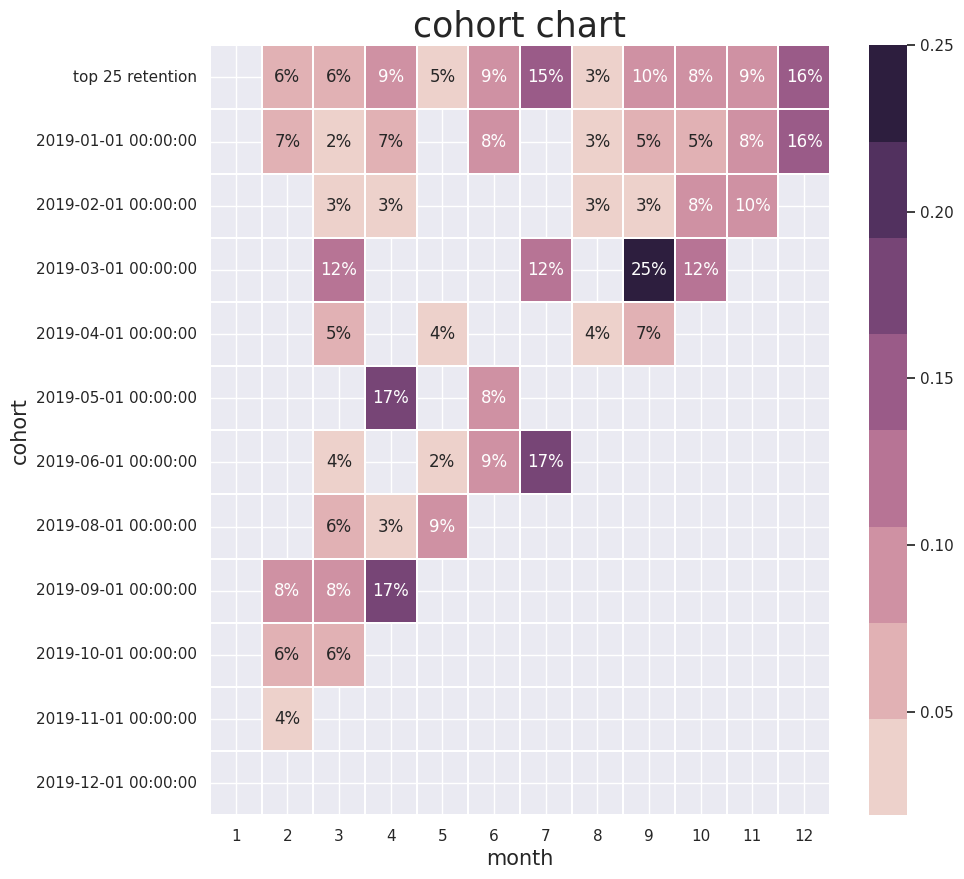

In [ ]:
# 총마케팅 비용을 사분위수로 나눈 후에 상위 25퍼센트에 해당하는 행들만
# 새로운 데이터프레임으로 추출
q3 = df_mar_on['총마케팅비용'].quantile(0.75)
mar_top = df_mar_on[df_mar_on['총마케팅비용'] > q3]

def get_month(x) :
  return dt.datetime(x.year,x.month,1)

mar_top['거래날짜달기준'] = mar_top['거래날짜'].apply(get_month)
grouping = mar_top.groupby('고객ID')['거래날짜달기준']
mar_top['최초거래날짜'] = grouping.transform('min')


def get_month_int (dframe,column):
    year = dframe[column].dt.year
    month = dframe[column].dt.month
    day = dframe[column].dt.day
    return year, month , day

invoice_year,invoice_month,_ = get_month_int(mar_top,'거래날짜달기준')
cohort_year,cohort_month,_ = get_month_int(mar_top,'최초거래날짜')

year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

mar_top['최초구매일로부터달'] = year_diff * 12 + month_diff + 1
#Count monthly active customers from each cohort
grouping = mar_top.groupby(['최초거래날짜', '최초구매일로부터달'])
cohort_data = grouping['고객ID'].apply(pd.Series.nunique)
# Return number of unique elements in the object.
cohort_data = cohort_data.reset_index()
cohort_counts = cohort_data.pivot(index='최초거래날짜',columns='최초구매일로부터달',values='고객ID')
# Retention table
cohort_size = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_size,axis=0) #axis=0 to ensure the divide along the row axis
# retention 평균 추가
monthly_avg_retention = retention.mean(axis=0)
monthly_avg_retention_df = pd.DataFrame(monthly_avg_retention).T
monthly_avg_retention_df.index = ['top 25 retention']
retention_avg = monthly_avg_retention_df
retention = pd.concat([monthly_avg_retention_df, retention])

def plot_cohort_chart(retention_matrix):
  # 첫번째 열의 경우 모두 100%로 의미있는 값이 아니기에 지운다.
    mask = retention_matrix.isnull()
    mask.iloc[:, 0] = True

    plt.figure(figsize = (10, 10))

    sns.heatmap(
        retention,
        mask=mask,
        annot=True,
        fmt='.0%',
        cmap=sns.cubehelix_palette(8),
        linewidths=.05
    )

    plt.title('cohort chart', fontsize=25)
    plt.xlabel('month', fontsize=15)
    plt.ylabel('cohort', fontsize=15)

    plt.show()

plot_cohort_chart(retention)

1-4-4-2)  온라인 마케팅 비용이 낮을 때

>온라인 마케팅 비용이 하위 25%에 해당할 때 구매한 고객의 리텐션 확인

* 시간이 지날수록 리텐션율이 감소한다.
  * 마지막 달의 리텐션율은 5%를 넘지 않는다.

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-29-811753b4a937>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mar_bottom['거래날짜달기준'] = mar_bottom['거래날짜'].apply(get_month)
<ipython-input-29-811753b4a937>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

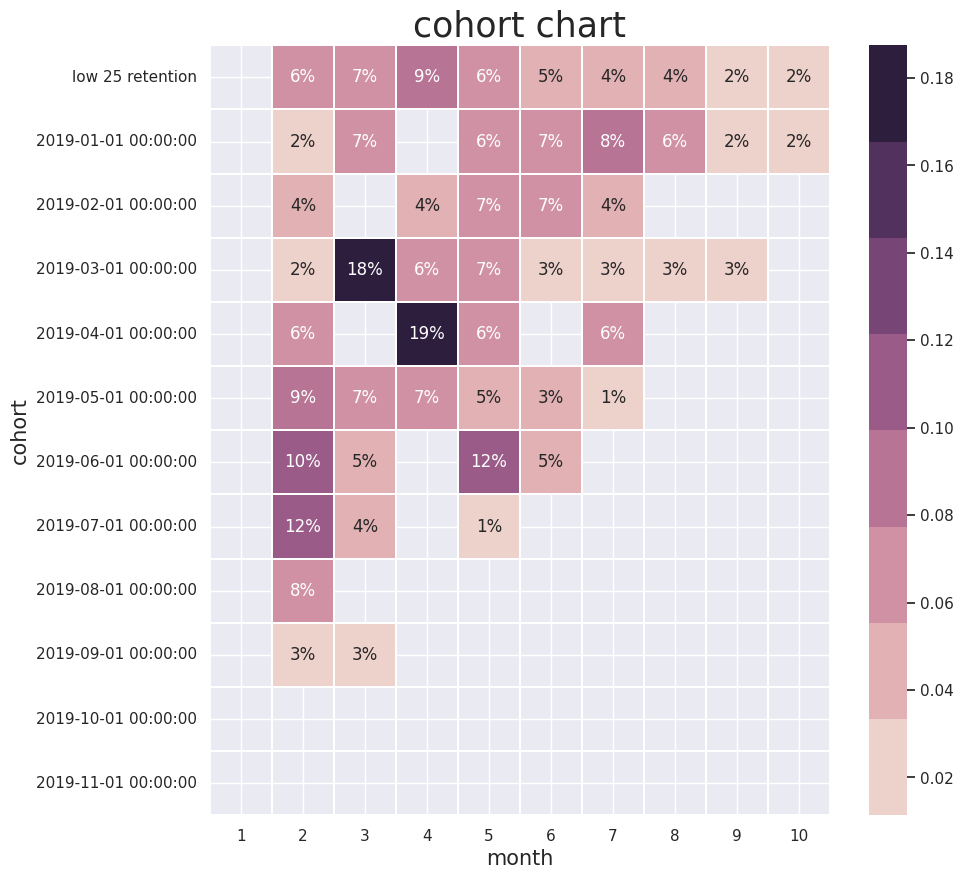

In [ ]:
# 총마케팅 비용을 사분위수로 나눈 후에 하위 25퍼센트에 해당하는 행들만
# 새로운 데이터프레임으로 추출
q1 = df_mar_on['총마케팅비용'].quantile(0.25)
mar_bottom = df_mar_on[df_mar_on['총마케팅비용'] < q1]

def get_month(x) :
  return dt.datetime(x.year,x.month,1)

mar_bottom['거래날짜달기준'] = mar_bottom['거래날짜'].apply(get_month)
grouping = mar_bottom.groupby('고객ID')['거래날짜달기준']
mar_bottom['최초거래날짜'] = grouping.transform('min')


def get_month_int (dframe,column):
    year = dframe[column].dt.year
    month = dframe[column].dt.month
    day = dframe[column].dt.day
    return year, month , day

invoice_year,invoice_month,_ = get_month_int(mar_bottom,'거래날짜달기준')
cohort_year,cohort_month,_ = get_month_int(mar_bottom,'최초거래날짜')

year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

mar_bottom['최초구매일로부터달'] = year_diff * 12 + month_diff + 1
#Count monthly active customers from each cohort
grouping = mar_bottom.groupby(['최초거래날짜', '최초구매일로부터달'])
cohort_data = grouping['고객ID'].apply(pd.Series.nunique)
# Return number of unique elements in the object.
cohort_data = cohort_data.reset_index()
cohort_counts = cohort_data.pivot(index='최초거래날짜',columns='최초구매일로부터달',values='고객ID')
# Retention table
cohort_size = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_size,axis=0) #axis=0 to ensure the divide along the row axis
# retention 평균 추가
monthly_avg_retention = retention.mean(axis=0)
monthly_avg_retention_df = pd.DataFrame(monthly_avg_retention).T
monthly_avg_retention_df.index = ['low 25 retention']
retention_avg = pd.concat([retention_avg, monthly_avg_retention_df])
retention = pd.concat([monthly_avg_retention_df, retention])

def plot_cohort_chart(retention_matrix):
  # 첫번째 열의 경우 모두 100%로 의미있는 값이 아니기에 지운다.
    mask = retention_matrix.isnull()
    mask.iloc[:, 0] = True

    plt.figure(figsize = (10, 10))

    sns.heatmap(
        retention,
        mask=mask,
        annot=True,
        fmt='.0%',
        cmap=sns.cubehelix_palette(8),
        linewidths=.1
    )

    plt.title('cohort chart', fontsize=25)
    plt.xlabel('month', fontsize=15)
    plt.ylabel('cohort', fontsize=15)

    plt.show()

plot_cohort_chart(retention)

1-4-4-3) 마케팅 비용이 높을 때 구매한 고객과 낮을 때 구매한 고객의 평균 리텐션 그래프

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


<Figure size 1000x600 with 0 Axes>

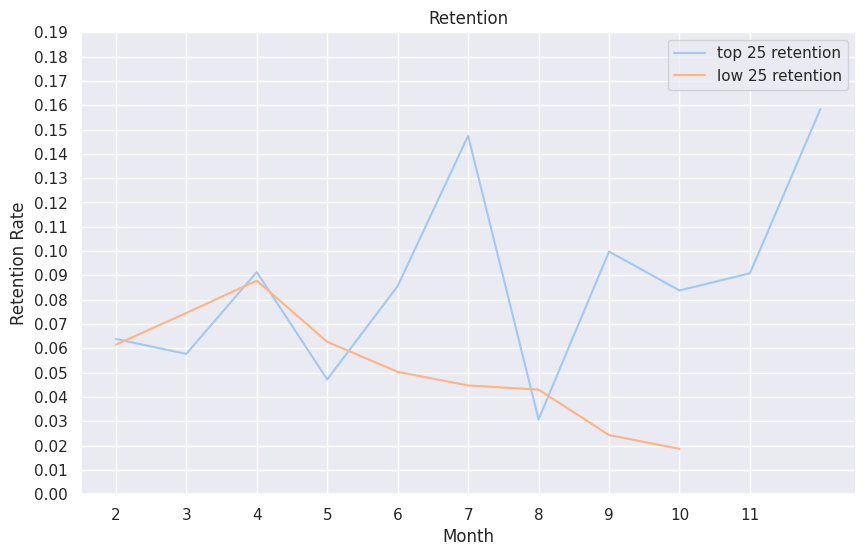

In [ ]:
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))

for row_label, row_data in retention_avg.iterrows():
    plt.plot(row_data.index[1:], row_data.values[1:], label=f'{row_label}')

plt.title('Retention')
plt.xlabel('Month')
plt.ylabel('Retention Rate')
plt.xticks(range(2, 12))
plt.yticks(np.arange(0, 0.2, 0.01))
plt.grid(True)
plt.legend()

# 그래프 표시
plt.show()

* 5월 중순 이전에는 마케팅 비용이 하위 25%일 때 구매한 고객의 리텐션율이 높은 구간이 보이지만, 5월 중순 이후에는 상위 25%일 때 구매한 고객의 리텐션이 훨씬 높아진다.
* 이를 보아 재구매율 증대를 위해 **마케팅 비용을 높히는 것이 장기적으로 보았을 때 큰 이득을 가져온**다는 것을 확인하였다.

#### **마케팅 분석을 통한 결론 :**

마케팅 비용이 증가할수록 ARPPU의 증가가 뚜렷하게 보였기 때문에 매출증대를 위해 마케팅 비용을 높히는 전략이 효과가 있을거다 (1-4-1)

크게 두드러지는 차이는 아니지만 오프라인 광고 비용을 높혔을 때 ARPPU가 더 많이 오르기 때문에 매출증대를 위한 효과가 좋다고 볼 수 있다. (1-4-3)

재구매율 증대를 위해 마케팅 비용을 높히는 것이 장기적으로 보았을 때 큰 이득을 가져온다. (1-4-4-3)

### 1-5) Discount_info


##### 쿠폰을 제공하는 달이 다름 → 10% (1,4,7,10) , 20% (2,5,8,11), 30% (3,6,9,12)_유진이 (Discount_info)

##### 10%일 때 구매횟수가 가장 많고, 30%일 때 평균금액이 가장 높다. 20%일 때 이용 고객들은 고객생애주기가 매우 낮다. 20%의 쿠폰을 제공하는 달에는 유독 거래량이 적은 걸로 보아 20% 쿠폰의 … 효력 …. 의심됨 …_유진이 (Discount_info)

### 1-6) 최종 데이터 만들기_나경

In [ ]:
df_on['년'] = df_on['거래날짜'].dt.year
df_on['월'] = df_on['거래날짜'].dt.month
df_on['일'] = df_on['거래날짜'].dt.day
month_dict = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6, 'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df_dis['월']= df_dis['월'].replace(month_dict)
df_mar.columns = ['거래날짜', '오프라인비용', '온라인비용']
df_mar['거래날짜'] = pd.to_datetime(df_mar['거래날짜'])

In [ ]:
# 1. onlines와 customer 데이터 합치기 (고객ID 기준으로)
#pd.merge(df_on,df_cus,on=['고객ID'],how='left')
# 2. onlines + customer + discount 데이터 합치기 (제품 카테고리 - 월 을 기준으로)
#pd.merge(pd.merge(df_on,df_cus,on=['고객ID'],how='left'),df_dis, on=['제품카테고리','월'],how='left')
# 3. onlines +customer + discount + maketing 데이터 합치기 (거래 날짜를 기준으로)
df = pd.merge(pd.merge(pd.merge(df_on,df_cus,on=['고객ID'],how='left'),df_dis, on=['제품카테고리','월'],how='left'),df_mar,on=['거래날짜'],how='left')

In [ ]:
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,고객생애가치,다음구매날짜,다음쿠폰상태,최종금액,재구매날까지의일,년,월,일,성별,고객지역,가입기간,쿠폰코드,할인율,오프라인비용,온라인비용
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,56.120493,2019-01-01,Used,153.71,0.0,2019,1,1,남,Chicago,12,ELEC10,10.0,4500,2424.5
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,56.120493,2019-01-01,Used,153.71,0.0,2019,1,1,남,Chicago,12,ELEC10,10.0,4500,2424.5
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,56.120493,2019-01-01,Not Used,2.05,0.0,2019,1,1,남,Chicago,12,OFF10,10.0,4500,2424.5
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,56.120493,2019-01-01,Used,87.65,0.0,2019,1,1,남,Chicago,12,SALE10,10.0,4500,2424.5
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,56.120493,2019-01-01,Used,16.50,0.0,2019,1,1,남,Chicago,12,AIO10,10.0,4500,2424.5


### 1-6) 최종 데이터를 기반으로 파생변수 설명

#2.RFM 기법과 제품 구매 가치를 통하여, 고객 세분화 진행 → 클러스터 1,2,3,4,5,6 _ 나경

### 2-1) RFM을 진행한 이유

거래횟수가 52924행인 것에 비해, 고객의 수는 1468명인 것을 볼 수 있다.
이는 한명의 고객이 여러번의 구매를 한 것으로 보이기 때문에, 거래 횟수가 2번 이상인 고객을 확인해보니 1402명 즉 95.5% 고객이 2번 이상 거래를 하는 것으로 볼 수 있다.

다만, 같은 날짜에 여러번 구매한 경우가 많아 고객 별로 다른 거래 날짜가 2개 이상인 경우에 고객의 수는 확인해보니 734명 즉 50% 정도인 것으로 보아 다른 날짜에 재방문 하는 고객의 수는 현저히 줄어드는 것을 확인해볼 수 있었다.


따라서 Recency : 얼마나 최근에 구매했는가,Frequency : 얼마나 자주 구매했는가,
Monetary : 얼마나 많은 금액을 지출했는가를 확인해볼 수 있는 RFM 기법을 사용하여 고객의 구매 패턴을 파악해보려고 한다.

In [ ]:
print(f"온라인거래가 일어난 횟수 : {len(df)}")
print(f"온라인거래를 이용한 고객 수 : {len(df['고객ID'].unique())}")
print(f"거래 횟수가 2번 이상인 고객 수  : {len(df.groupby('고객ID')['거래날짜'].size()[df.groupby('고객ID')['거래날짜'].size() > 1])}")
print(f"고객별로 서로 다른 거래 날짜가 두 개 이상인 고객 수  : {len(df.groupby('고객ID')['거래날짜'].nunique()[df.groupby('고객ID')['거래날짜'].nunique() > 1])}")

온라인거래가 일어난 횟수 : 52924
온라인거래를 이용한 고객 수 : 1468
거래 횟수가 2번 이상인 고객 수  : 1402
고객별로 서로 다른 거래 날짜가 두 개 이상인 고객 수  : 734


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# 원본 데이터셋 복사

rfm_online_sales = df.copy()
rfm_online_sales['최종가격'] = rfm_online_sales['평균금액']*rfm_online_sales['수량']
# 날짜 형식 변환
rfm_online_sales['거래날짜'] = pd.to_datetime(rfm_online_sales['거래날짜'])

# 데이터 내 마지막 날짜 계산
last_date = rfm_online_sales['거래날짜'].max()

# Recency 계산
recency_data = rfm_online_sales.groupby('고객ID')['거래날짜'].max().reset_index()
recency_data['Recency'] = (last_date - recency_data['거래날짜']).dt.days

# Frequency 계산
frequency_data = rfm_online_sales.groupby('고객ID')['거래ID'].count().reset_index()
frequency_data.rename(columns={'거래ID': 'Frequency'}, inplace=True)

# Monetary 계산
rfm_online_sales['SalesValue'] = rfm_online_sales['수량'] * rfm_online_sales['최종가격']
monetary_data = rfm_online_sales.groupby('고객ID')['SalesValue'].sum().reset_index()
monetary_data.rename(columns={'SalesValue': 'Monetary'}, inplace=True)

# RFM 데이터 결합
rfm_data = recency_data.merge(frequency_data, on='고객ID').merge(monetary_data, on='고객ID')

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# rfm_data : 고객별로 R, F, M 값 구함
rfm_data.head(2)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,고객ID,거래날짜,Recency,Frequency,Monetary
0,USER_0000,2019-09-15,107,2,41.99
1,USER_0001,2019-11-02,59,60,413396.44


### 2-2) 제품 구매가치를 구해서, 포함시킨 이유

고객이 구매한 상품의 특성 또한 고객의 구매 영향에 미치기도 하는데 RFM 분석은  R,F,M 3가지 요인으로만 분석한다는 단점이 존재한다. 따라서 고객이 어떠한 제품을 구입하였는지까지 고려할 수 있는 P (product) 요인을 추가한 다음 R,F,M,P 값을 사용하여 고객 세분화를 진행해보려고 한다.

Product 요인을 추가하는 방법

1. Onlinesales_info 데이터에서 제품 카테고리별 구매된 횟수 (count)
2. 제품 카테고리별 구매된 금액 / 구매된 횟수 (1회 주문 금액)
3. (count) * (1회 주문금액)을 곱해서 순차적으로 가장 낮은 값을 가지는 제품 카테고리는 1을 갖도록 가장 높은 값을 가지는 카테고리는 20의 값을 가지게 함 (구매가치)
4. 고객이 구매한 모든 제품 카테고리에 대하여 각각 제품 카테고리별 구매한 횟수 * 각 카테고리별 구매가치를 구한다음 더한다 (고객_지표)

  ex) A라는 고객이 Housewares를 10번사고, Android를 5번 샀을 때, 10x1 (housewares 구매한 횟수 * housewares 구매가치) + 5x2 (Android를 구매한 횟수 * Android를 구매가치) = 20 -> A라는 고객의 최종고객지표는 20을 가진다.

In [ ]:
# 1. Onlinesales_info 데이터에서 제품 카테고리별 구매된 횟수 (count)
show_df = pd.DataFrame()
product_count = []
product_price = []
for value in list(df['제품카테고리'].value_counts().index):
  count = len(df.loc[df['제품카테고리']==value])
  product_count.append(count)
  price = df.loc[df['제품카테고리']==value,'평균금액'].sum()/count
  product_price.append(price)
count_df = pd.DataFrame({'product':list(df['제품카테고리'].value_counts().index),'count':product_count})
count_df.reset_index(drop=True,inplace=True)
show_df = count_df.set_index('product')
count_dict = count_df.set_index('product')['count'].to_dict()

# 2.제품 카테고리별 구매된 금액 / 구매된 횟수 (1회 주문 금액)
price_df = pd.DataFrame({'product':list(df['제품카테고리'].value_counts().index),'price':product_price})
price_df.sort_values(by='price', ascending=False,inplace=True)
price_df.reset_index(drop=True,inplace=True)
show_df = pd.concat([show_df,price_df.set_index('product')],axis=1)
price_dict = price_df.set_index('product')['price'].to_dict()

# 3. (count) * (1회 주문금액)을 곱해서 가장 낮은 값을 가지는 제품 카테고리는 부터 1을 갖도록 가장 높은 값을 가지는 카테고리는 20의 값을 가지도록 카테고리별 구매가치 계산
product_values_for_df = [count_dict[product] * price_dict[product] for product in count_dict]
product_values = {product: count_dict[product] * price_dict[product] for product in count_dict}
value_df = pd.DataFrame({'product':list(df['제품카테고리'].value_counts().index),'count*price':product_values_for_df})
value_df.sort_values(by='count*price', ascending=False,inplace=True)
value_df.reset_index(drop=True,inplace=True)
show_df = pd.concat([show_df,value_df.set_index('product')],axis=1)
sorted_products = sorted(product_values, key=product_values.get)
index_dict = {index: i for i, index in enumerate(sorted_products, start=1)}
show_df.sort_values('count*price',inplace=True)
show_df['구매가치'] = list(range(1,21))
show_df

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,count,price,count*price,구매가치
product,,,,
Housewares,122,2.060574,251.39,1
Android,43,15.903488,683.85,2
More Bags,46,19.776957,909.74,3
Bottles,268,3.437201,921.17,4
Fun,160,6.743812,1079.01,5
Google,105,16.446190,1726.85,6
Accessories,234,8.211068,1921.39,7
Waze,554,6.607852,3660.75,8
Backpacks,89,80.046404,7124.13,9


In [ ]:
# 4.고객이 구매한 제품 카테고리별 구매한 횟수 * 각 카테고리별 구매가치를 구한다음 더해 최종 고객 지표를 만듦
customer_product_count = df.groupby(['고객ID', '제품카테고리']).size().reset_index(name='구매_횟수')
customer_product_count['제품_가치'] = customer_product_count['제품카테고리'].map(index_dict)
customer_product_count['최종_제품_가치'] = customer_product_count['구매_횟수'] * customer_product_count['제품_가치']
customer_value_indicator = customer_product_count.groupby('고객ID')['최종_제품_가치'].sum().reset_index(name='고객_지표')
customer_value_indicator.head(3)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,고객ID,고객_지표
0,USER_0000,32
1,USER_0001,1034
2,USER_0002,344


In [ ]:
rfm_data= pd.merge(rfm_data,customer_value_indicator,on='고객ID')
rfm_data.head(3)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,고객ID,거래날짜,Recency,Frequency,Monetary,고객_지표
0,USER_0000,2019-09-15,107,2,41.99,32
1,USER_0001,2019-11-02,59,60,413396.44,1034
2,USER_0002,2019-10-19,73,23,33503.96,344



### 2-3) R , F, M, P를 고려하여 RFMP SCORE를 만들기


앞에서  구한 R, F, M, P 값들을 고려해서 최종 RFMP SCORE를 만들기 위해서 기계학습 기법과 기술 통계량을 활용하여, 고객이 갖는 변수의 특성을 고려하면서도 객관화된 방법으로 가중치를 산출하고자 한다. ( 가중치를 선정하는 기법은 "RFM 모형의 가중치 선택에 관한 연구"의 내용을 참고하였다.)



1. R, F, M , P변수에 대한 데이터 표준화
2. Elbow Method 방법을 활용한 최적의 K값 탐색
3. 각 지표별로 K-Means Clustering 알고리즘을 활용하여 전체 고객 데이터를 K개의 그룹으로 군집화
4. K개로 분류된 그룹1, 그룹2, …, 그룹K에 대하여 각각 R, F, M ,P값의 CV(Coefficient ofvariation, 변동계수)를 산출하고 전체 집단과의 비율을 활용
5. w1,w2,w3,w4 값을 구하기
6. W1, W2, W3, W4값을 구하기
7. 구하고자 하는 값 : W1*R + W2*F + W3*M + W4*P



#### 5,6번에 대하여 w1~w4 / W1 ~ W4를 구하는 방법 (식으로 작성)

변동 계수(CV)는 데이터의 흩어짐을 나타내는 지표이며, 변동 계수가 작을수록 데이터의 흩어짐이 작다는 것을 의미한다.
해당 열의 wn (n= R,F,M,P)이 크다는 것은 n열에 대하여 군집화 결과가 다른 열에 비해 더 작은 변동 계수를 갖고 있어서, 데이터의 흩어짐이 작다는 것을 의미합니다. 이는n열의 군집화가 다른 열에 비해 더 일관된 패턴을 나타내고 있으며, 따라서 데이터의 특성을 더 잘 반영하기 때문에 다른 열들보다 큰 가중치를 가지게 해 최종 점수를 계산하는 방식이다.


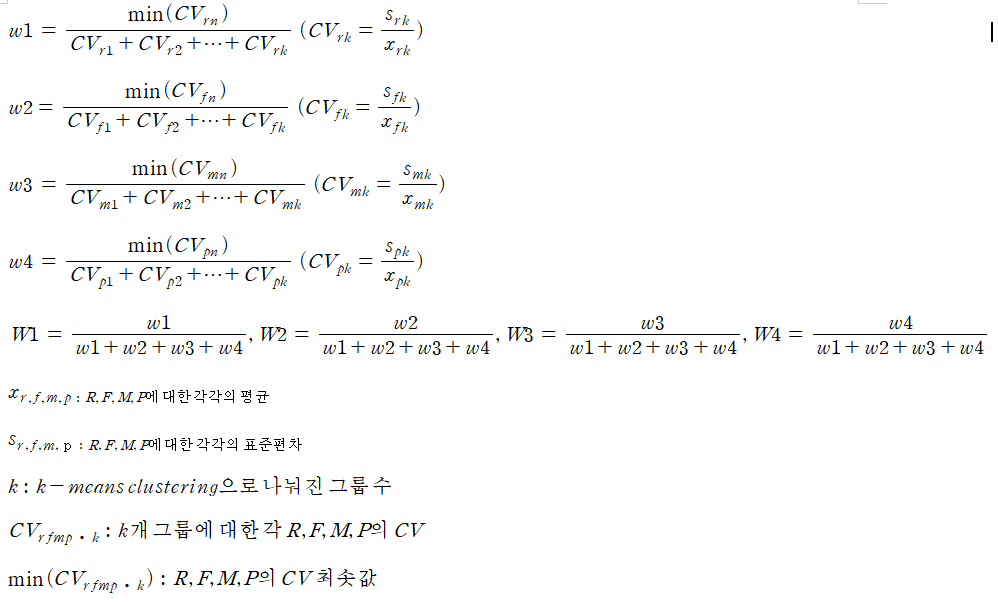

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


# 2. Elbow Method 그래프를 통하여 R,F,M,P에 대하여 최적의 k개수 정하기
def plot_elbow_curve(data, col,max_clusters=10):
    distortions = []
    for i in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        kmeans.fit(data)
        distortions.append(kmeans.inertia_)

    # Elbow Method 그래프 플로팅
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_clusters + 1), distortions, marker='o', linestyle='--')
    plt.xlabel('Number of clusters')
    plt.ylabel('Distortion')
    plt.title(col +'의 Elbow Method 그래프')
    plt.show()

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


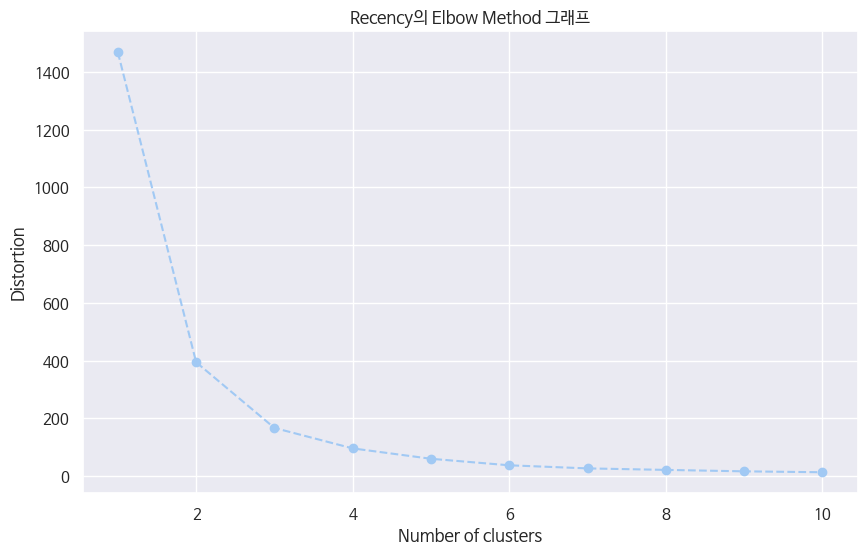

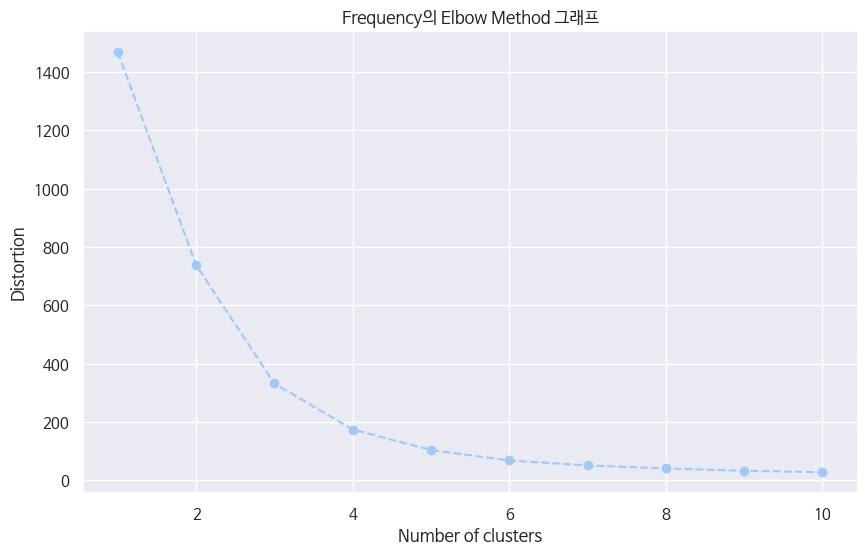

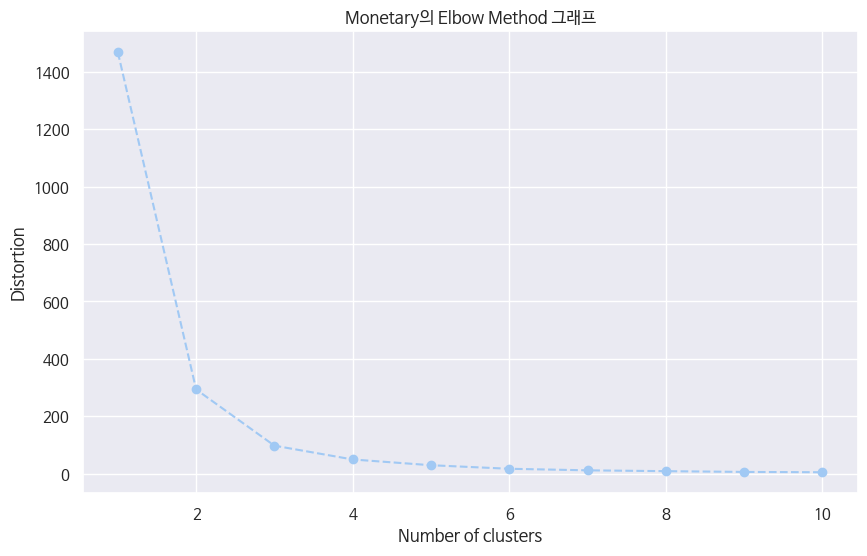

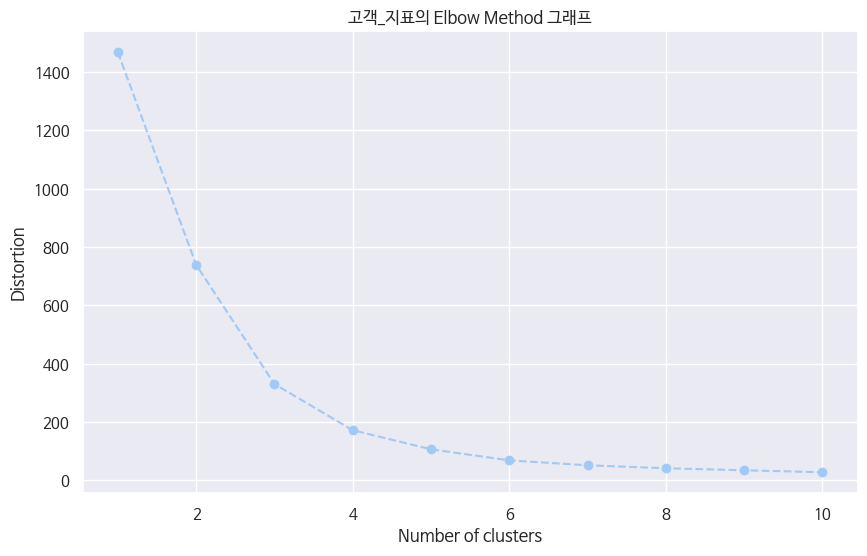

In [ ]:
import warnings
warnings.filterwarnings("ignore")
for col in ['Recency','Frequency','Monetary','고객_지표']:
  scaler = StandardScaler() # 각 지표별로 클러스터링을 진행하기 위하여 표
  df_scale = pd.DataFrame(scaler.fit_transform(rfm_data[[col]]))
  plot_elbow_curve(df_scale,col)

R,F,M,P에 대하여 elbow method 그래프를 통하여
R은 군집을 3개로 , F는 군집을 4개로, M은 군집을 2개로, P는 군집을 4개로 두어 각각 kmeans 군집화를 실행하고, 각 지표별 군집에 대한 기술통계량을 사용해서 최종적으로 사용하는 가중치 값을 결정하려고 한다

In [ ]:
# 5.w1,w2,w3,w4 값을 구하는 함수, rfm_data, 구하고 싶은 열의 이름, 해당 열이 진행하기로 한 클러스터의 개수 (2번에서 정함)
def geteachcolumnsweight(df_p,col,cluster_num):
  # 1.R, F, M , P변수에 대한 데이터 표준화
  scaler = StandardScaler()
  df_scale = pd.DataFrame(scaler.fit_transform(df_p[[col]]))
  df_scale.columns = [col]
  # 3. 각 지표별로 K-Means Clustering 알고리즘을 활용하여 전체 고객 데이터를 K개의 그룹으로 군집화
  kmeans_model = KMeans(n_clusters= cluster_num, random_state= 100)
  kmeans_model.fit(df_scale) # 학습
  df_p['Cluster'] = kmeans_model.predict(df_scale)
  CV_list = []
  weight_list = []
  for i in range(cluster_num): # 앞에 식에서 설명했던 w1,w2,w3,w4를 구하는 방식이다.
    mean_list=[]
    std_list = []
    CV_list.append(math.sqrt(df_p.loc[df_p['Cluster']==i].var()[0])/df_p.loc[df_p['Cluster']==i].mean()[0])
  weight = min(CV_list) / sum(CV_list)
  return weight

# 6.W1, W2, W3, W4값을 구하는 함수
def getfinalweight(w1,w2,w3,w4):
  final_sum = w1+w2+w3+w4
  W1 = w1/ final_sum
  W2 = w2/ final_sum
  W3 = w3/ final_sum
  W4 = w4/ final_sum
  return W1,W2,W3,W4

# 5번에서 말한 w1,w2,w3,w4를 구하기 위해서 함수 호출
w1 = geteachcolumnsweight(rfm_data,'Recency',3)
w2 = geteachcolumnsweight(rfm_data,'Frequency',4)
w3 = geteachcolumnsweight(rfm_data,'Monetary',2)
w4 = geteachcolumnsweight(rfm_data,'고객_지표',4)
print(f"변동계수를 사용하여 구한 가중치는 다음과 같다, 해당 값이 크다는 것은 군집화가 다른 열에 비해 더 일관된 패턴을 가졌다는 것을 의미한다.  w1:{w1}, w2:{w2}, w3:{w3}, w4:{w4},")

# 6번에서 말한 W1,W2,W3,W4를 구하기 위해서 함수 호출
W1,W2,W3,W4 = getfinalweight(w1,w2,w3,w4)
print(f"각 열에 쓰일 최종 가중치 값은 다음과 같다 W1:{W1}, W2:{W2}, W3:{W3}, W4:{W4},")
rfm_data.drop(columns=['Cluster'],inplace=True)

# 7.구하고자 하는 값 : W1R + W2F + W3M + W4P
rfm_data['RFMP_SCORE'] = rfm_data['Recency']*W1+ rfm_data['Frequency']*W2 + rfm_data['Monetary']*W3 +  rfm_data['고객_지표']*W4

변동계수를 사용하여 구한 가중치는 다음과 같다, 해당 값이 크다는 것은 군집화가 다른 열에 비해 더 일관된 패턴을 가졌다는 것을 의미한다.  w1:0.13820795836583935, w2:0.17492439386570188, w3:0.3550536911120684, w4:0.1734079338117129,
각 열에 쓰일 최종 가중치 값은 다음과 같다 W1:0.16422165808861536, W2:0.20784891362574265, W3:0.421882404995563, W4:0.20604702329007893,



### 2-4) RFMP SCORE을 통해 6개의 고객으로 나눔

In [ ]:
rfm_data['cluster'] = pd.qcut(rfm_data['RFMP_SCORE'], 6, labels=[6,5,4, 3, 2, 1])
rfm_data.head(3)
for i in range(1,7):
  print(f"클러스터 {i}의 RFMPSCORE 평균 {rfm_data.loc[rfm_data['cluster']==i,'RFMP_SCORE'].mean()} , 클러스터 {i}에 속하는 고객의 수 :{len(rfm_data.loc[rfm_data['cluster']==i,])}")

클러스터 1의 RFMPSCORE 평균 168545.1856848946 , 클러스터 1에 속하는 고객의 수 :245
클러스터 2의 RFMPSCORE 평균 10282.659123275647 , 클러스터 2에 속하는 고객의 수 :244
클러스터 3의 RFMPSCORE 평균 4133.093503593459 , 클러스터 3에 속하는 고객의 수 :245
클러스터 4의 RFMPSCORE 평균 1835.7193284576113 , 클러스터 4에 속하는 고객의 수 :244
클러스터 5의 RFMPSCORE 평균 709.2279114662125 , 클러스터 5에 속하는 고객의 수 :245
클러스터 6의 RFMPSCORE 평균 151.26426946910917 , 클러스터 6에 속하는 고객의 수 :245


In [ ]:
df = df.merge(rfm_data[['고객ID','cluster']],on='고객ID')
df.head(2)

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,성별_x,고객지역_x,가입기간_x,총구매금액,구매횟수,평균구매금액,평균구매빈도,고객생애가치,다음구매날짜,다음쿠폰상태,최종금액,재구매날까지의일,년,월,일,성별_y,고객지역_y,가입기간_y,쿠폰코드,할인율,오프라인비용,온라인비용,cluster
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,남,Chicago,1.0,20483.98,297,68.96963,0.813699,56.120493,2019-01-01,Used,153.71,0.0,2019,1,1,남,Chicago,12,ELEC10,10.0,4500,2424.5,1
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,남,Chicago,1.0,20483.98,297,68.96963,0.813699,56.120493,2019-01-01,Used,153.71,0.0,2019,1,1,남,Chicago,12,ELEC10,10.0,4500,2424.5,1


In [ ]:
#df.to_csv('/content/drive/MyDrive/데이콘/이커머스 고객 세분화 분석 아이디어 경진대회/cluster.csv')

# 3.클러스터 포함

### 3-0) 클러스터 별 구매 패턴 파악 _나경
클러스터 1은 거래량 , 구매 수량, 평균 금액량 , 한번 구매시 평균 금액량이 모두 가장 높은 고객이며 클러스터 6으로 가면 갈수록, 해당 값들이 점점 감소하는 것을 확인할 수 있다.
따라서 각 클러스터 고객들을 아래과 같이 정의하도로 하겠다.

클러스터1 : VIP

클러스터2 : Diamond

클러스터3 : Platinum

클러스터4 : Gold

클러스터5 : Silver

클러스터6 : Bronze

.


거래량의 65%를 차지할만큼, 구매가 활발하게 이뤄지는 VIP/Diamond 집단에 대해서는 집단별 특성을 반영하여 이미 구매를 잘하고 있는 제품 이외에 고객이 다양한 제품을 구매할 수 있는 크로스셀링 기법을 목표로 한다.

거래량의 26%를 차지하는 정도로 많이는 아니지만 그래도 자주 구매하는 Platinum/Gold 집단에 대해서는 재구매율을 높이기 위하여 제품 추천을 목표로 한다.

거래량의 9%를 차지하는 정도로 구매가 잘 이뤄지지 않는 Silver/Bronze 집단에 대해서는 이탈방지를 위하여 주카테고리 제공하는 것을 목표로 한다.

.


위 세가지 방법들에 대한 자세한 설명은 각 카테고리 부분에서 진행하도록 하겠다.





In [ ]:
#df = pd.read_csv('/content/drive/MyDrive/데이콘/이커머스 고객 세분화 분석 아이디어 경진대회/cluster.csv',index_col=0)
df['최종금액'] = df['평균금액']*df['수량']
# 세그먼트 분리
VIP = df[df['cluster'] == 1]
Diamond = df[df['cluster'] == 2]
Platinum = df[df['cluster'] == 3]
Gold = df[df['cluster'] == 4]
Silver = df[df['cluster'] == 5]
Bronze = df[df['cluster'] == 6]

df_list = [VIP,Diamond,Platinum,Gold,Silver,Bronze]
value_df = pd.DataFrame()
for i,df_p in enumerate(df_list):
  total_count= int(len(df_p))
  count_value= int(sum(df_p.groupby('고객ID')['수량'].sum()))
  price_value = int(sum(df_p.groupby('고객ID')['최종금액'].sum()))
  once_price = int(price_value/total_count)
  value_list = [total_count,count_value,price_value,once_price]
  col = str(i+1) + '클러스터의 고객들의 구매이력'
  new_df = pd.DataFrame({col:value_list})
  new_df.index = ["총 거래량","총 구매 수량","평균금액량",'한번 구매 시 평균금액량']
  value_df = pd.concat([value_df,new_df],axis=1)
value_df

,1클러스터의 고객들의 구매이력,2클러스터의 고객들의 구매이력,3클러스터의 고객들의 구매이력,4클러스터의 고객들의 구매이력,5클러스터의 고객들의 구매이력,6클러스터의 고객들의 구매이력
총 거래량,21776,12694,8852,5036,3331,1235
총 구매 수량,147307,47897,24230,10892,5951,1756
평균금액량,2176194,1101696,734206,409354,203805,45537
한번 구매 시 평균금액량,99,86,82,81,61,36


### 3-1) VIP /Diamond 고객  : 제품 구매 카테고리를 늘리는 방안 (주구매층) _나경

이용 카테고리수의 증가에 따라 고객생애주기_유진이

VIP /Diamond는 전체 거래량의 65%를 차지하고 있을만큼, 거래량 / 구매수량 모두 높은 고객이다. 앞에서 보여준 이용 카테고리수의 증가에 따라 고객생애주기가 높아지는 것으로 보아 VIP /Diamond2에게는 이미 거래했던 카테고리 개수보다 더 많은 카테고리 수를 이용할 수 있게끔 해당 고객이 구매한 카테고리를 바탕으로 다른 카테고리의 제품을 추천해주는 크로스셀링 진행하려고 한다.

1. 고객이 주문한 제품 카테고리의 **종류 개수** 구하기 : **n** (n=1~20)

2. 고객이 주문한 유니크한 제품 카테고리 **종류 리스트** 구하기 : **customer_list**

3. 고객이 추가로 제품 카테고리를 구매하도록 목표로 삼는 제품 카테고리의 **종류 개수** 구하기 : **K** (n이 짝수면 k = n+2, n이 홀수면 k= n+1)

4. 제품 카테고리의 종류 개수를 k개와 k+1개를 구매하는 유니크한 제품 카테고리를 리스트가 존재할 때 각 제품 카테고리 별로 리스트 안에 몇번 담겨져있는 지를 파악하여 많이 담기는 **k개의 제품 카테고리를 발견**하기 : **target_list**.

5. target_list는 고객이 목표로 삼는 카테고리 종류의 개수를 사는 사람들이 주로 사는 품목이므로, 만약 해당 고객이 target_list에 들어있는 제품을 구매하지 않는다면, **target_list 안에 들어있는 제품을 해당 고객에게 추천**해주기.

6. **recommend_list : target_list와 customer_list 차집합** ,
recommend _list에 들어있는 개수가 (k-n : 고객이 추가로 사야하는 제품 카테고리 개수)보다 크다면, recommend list에 들어있는 제품 카테고리 중 어느 제품을 사야할 지를 결정하기 위하여 해당 df에 대해서 **장바구니 분석**을 통해서 A제품을 사면 B 제품을 사는 경향이 있다 라는 결과에 대해서 [A,B] 이런식으로 리스트를 저장한다.최종적으로는 [[A,B],[B,C],[B,D],[B,C,D],[A,D]] 이런 식으로 저장되어있음 : **basket_list**

7. recommend_list 안에 들어있는 제품 카테고리(X)와 customer_list 안에 들어있는 제품 카테고리(y)를 하나씩 비교해가면서, **둘의 값([X,Y])이 basket_list에 들어있다면 X에 대해서 +1** 의 값을 가지도록 한다.
따라서 최종적으로는 recommend_list안에 들어있는 제품 카테고리들 중 count가 많이된 **제품 순서대로 고객이 추가적으로 사야하는 카테고리 수만큼 추천**해준다.
(이때 모든 [X,Y]가 basket_list에 없다면 다 0의 값을 가지기 때문에 이때는 무작위로 제품 카테고리를 추천해준다.)

### 예시 (step1 ~ step5까지의 예시)
A라는 고객이 구매한 유니크한 카테고리 종류 개수 5

고객이 주문한 유니크한 제품 카테고리 종류 리스트 : ['a','b','c','d','e']

고객이 추가로 제품 카테고리를 구매하도록 목표로 삼는 제품 카테고리의 종류 개수 : 6개

- 제품 카테고리의 종류 개수가 6개와 7개를 구매하는 고객들의 수 : 3명

- target_list

product_list = ['a','b','c','d','e','f','g','h','i']

cus1 =  ['a','b','c','d','e','f']

cus2 =  ['a','b','c','d','e','i]

cus3 =  ['a','b','c','h','e','i']

-> a : 3번, b :3번, c:3번,d:2번,e:3번,f:1번,g:0번, h: 1번 ,i:2번 이런식으로 counting한 후 내림차순으로 6번째 제품까지 고름

target_list : ['a','b','c','d','e','i']

- recommend list : ['i']



In [ ]:
# 1.고객이 주문한 제품 카테고리의 종류 개수 구하기 : n (n=1~20)
# 2. 고객이 주문한 유니크한 제품 카테고리 종류 리스트 구하기 : customer_list

def cutertomerpurchase_numandlist(df_p, user_id):
  users_index = df_p[df_p['고객ID'] == user_id].index
  user_list = []
  for idx in range(len(users_index)):
    user_list.append(df_p.loc[users_index[idx],'제품카테고리'])
    user_list = set(user_list)
    user_list = list(user_list)
  return len(user_list), user_list

In [ ]:
# 3. 고객이 추가로 제품 카테고리를 구매하도록 목표로 삼는 제품 카테고리의 종류 개수 구하기
def target_num(n):
  if n%2 ==0:
    target = n+2
  else:
    target = n+1
  return target

In [ ]:
# 4.제품 카테고리의 종류 개수를 k개와 k+1개를 구매하는 유니크한 제품 카테고리를 리스트가 존재할 때 각 제품 카테고리 별로 리스트 안에 몇번 담겨져있는 지를 파악하여 많이 담기는 k개의 제품 카테고리를 발견하기
def gettargetcategory(df_p,k):
  product_list = df['제품카테고리'].unique() # 전체 df에 존재하는 제품카테고리 개수
  df_grouped = pd.DataFrame(df_p.groupby('고객ID')['제품카테고리'].nunique()) # 각 고객별로 구매한 제품카테고리의 종류수가 담겨져 있는 df

  user_id_list = []
  for i in range(len(df_grouped)):
    if k<=df_grouped.iloc[i].values[0] <= k+1:
      user_id_list.append(df_grouped.index[i]) # k개와 k+1개의 제품 카테고리를 구매하는 고객의 고객 ID 리스트

  purchase_product = []
  for user in user_id_list: # 하나의 고객에 대해서
      users_index = df_p[df_p['고객ID'] == user].index # 해당 고객이 구매한 이력이 있는 index를 찾음
      user_purchase = []
      for idx in range(len(users_index)):
        user_purchase.append(df_p.loc[users_index[idx],'제품카테고리']) # 고객이 구매한 이력에서 구매한 제품 카테고리를 모두 저장
        user_purchase = set(user_purchase) # 유니크한 제품 카테고리만 구하기
        user_purchase = list(user_purchase)
      purchase_product.append(user_purchase) # k개 or k+1개의 유니크한 제품 카테고리를 구매한 고객들이 산 유니크한 제품 카테고리 저장

  NestUSA_count = 0;Office_count = 0;Apparel_count =0;Bags_count = 0;Drinkware_count = 0;Lifestyle_count = 0;Waze_count = 0;
  Headgear_count = 0;Fun_count = 0;Google_count = 0;NotebooksJournals_count = 0;
  Backpacks_count = 0;NestCanada_count = 0;Housewares_count = 0;Bottles_count = 0;Nest_count = 0;Android_count = 0
  Accessories_count = 0;GiftCards_count = 0;MoreBags_count = 0
  count_list = [NestUSA_count, Office_count, Apparel_count, Bags_count, Drinkware_count, Lifestyle_count, Waze_count,
                Headgear_count, Fun_count, Google_count, NotebooksJournals_count,
                Backpacks_count, NestCanada_count, Housewares_count, Bottles_count, Nest_count, Android_count,
                Accessories_count, GiftCards_count, MoreBags_count]

  for customer_product in purchase_product: # customer_product : 각 고객이 구매한 제품 카테고리가 저장되어 있음
      for j, pro in enumerate(product_list): # 전체 df가 가지고 있는 각 제품 카테고리에 대해서
          if pro in customer_product: # 고객이 구매한 제품 카테고리라면
              count_list[j] += 1 # 해당 제품에 대해서 +1을 해준다
  # counting이 많이 되었다는건, 해당 고객들에 대해서 많이 구매된 제품이기 때문에 counting된 횟수를 기준으로 target 숫자인 k만큼 뽑아낸다
  target_list = [product_list[i] for i in sorted(range(len(count_list)), key=lambda x: count_list[x], reverse=True)[:k]]
  return target_list

In [ ]:
# 6.해당 df에 대해서 장바구니 분석을 통해서 A제품을 사면 B 제품을 사는 경향이 있다 라는 결과에 대해서 [A,B] 이런식으로 리스트를 저장한다.
# 최종적으로는 [[A,B],[B,C],[B,D],[B,C,D],[A,D]] 이런 식으로 저장되어있음 : basket_list
def encoding(x):
    if x<=0:
        return 0
    if x>=1:
        return 1

def get_basket_list(df,column):
  Trans=df.groupby(['고객ID','거래ID']).size().reset_index(name='고유_거래ID')
  Trans['고유_거래ID']=np.arange(1,len(Trans)+1)
  df = df.merge(Trans[['고객ID','거래ID','고유_거래ID']],on=['고객ID','거래ID'])
  Transaction = df.groupby(['고유_거래ID',column])[column].count().reset_index(name='Count')
  basket = Transaction.pivot_table(index='고유_거래ID', columns=column, values='Count', aggfunc='sum').fillna(0)
  # 0, 1 로 변환해주는 함수
  # applying the function to the dataset
  basket = basket.applymap(encoding)
  freq_item = apriori(basket, min_support = 0.01,use_colnames = True)
  rules = association_rules(freq_item, metric = "lift", min_threshold = 1)
  rules.sort_values('confidence', ascending = False, inplace = True)
  basket_list = []
  for i in range(len(rules)):
    mini_list = []
    mini_list.append(next(iter(rules['antecedents'].values[i])))
    mini_list.append(next(iter(rules['consequents'].values[i])))
    basket_list.append(mini_list)
  return basket_list

# 7.제품 카테고리들 중 count가 많이된 제품 순서대로 고객이 추가적으로 사야하는 카테고리 수만큼 추천
def apiori_recommend(customer_list,target_list,basket_list):
  recommend_list = list(set(target_list).difference(customer_list))
  num = len(target_list) - len(customer_list)
  if len(recommend_list) <=num:
    final_product_limit = recommend_list
  else: # recoomend_list 중에 num 만큼 뽑아야됨
    similarity_scores = [0] * len(recommend_list)
    for idx,rec in enumerate(recommend_list):
      for cus in customer_list:
        list1 =[]
        list1.append(rec)
        list1.append(cus)
        for sublist in basket_list:
          if all(item in sublist for item in list1):
            similarity_scores[idx] +=1
    final_product_limit = [recommend_list[i] for i in sorted(range(len(similarity_scores)), key=lambda x: similarity_scores[x], reverse=True)[:num]]
  return final_product_limit

In [ ]:
# 5. target_list는 고객이 목표로 삼는 카테고리 종류의 개수를 사는 사람들이 주로 사는 품목이므로, 만약 해당 고객이 target_list에 들어있는 제품을 구매하지 않는다면, target_list 안에 들어있는 제품을 해당 고객에게 추천해주기.
def get_recommend_list(df_p,user_list,target_list):
  recommend_list = list(set(target_list).difference(user_list))
  num = len(target_list) - len(user_list)
  if len(recommend_list) <= num: # 추천 리스트의 수 == 고객이 사야하는 카테고리의 수 -> 추천리스트 구매
    pass
  else: # 추천리스트수 >= 고객이 사야하는 카테고리의 수 -> step 6,7의 함수를 불러와서 추천리스트 중 장바구니 분석 결과를 사용하여 고객이 사야하는 카테고리의 수만큼만 뽑아 추천해준다
    basket_list = get_basket_list(df_p,'제품카테고리')
    plus_rec= apiori_recommend(user_list,target_list,basket_list)
    recommend_list = plus_rec
  return recommend_list

In [ ]:
# 각 스텝별로 함수를 사용하는 방법 (예시)
user_id = 'USER_1358'
# step 1,2
n,customer_list = cutertomerpurchase_numandlist(VIP,user_id)
# step 3
k = target_num(n)
# step4
target_list = gettargetcategory(VIP,k)
# step 5,6,7
recommend_list = get_recommend_list(VIP,customer_list,target_list)

print(f"{user_id}의 고객이 구매한 제품 카테고리 수는 {n}개이며, 구매한 제품카테고리는 {customer_list}이다.")
print(f"고객이 도달해야하는 제품 카테고리의 개수는 {k}이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 {recommend_list}이다. ")

USER_1358의 고객이 구매한 제품 카테고리 수는 15개이며, 구매한 제품카테고리는 ['Office', 'Backpacks', 'Google', 'Headgear', 'Nest-Canada', 'Apparel', 'Bags', 'Waze', 'Drinkware', 'Lifestyle', 'Fun', 'Housewares', 'Bottles', 'Notebooks & Journals', 'Nest-USA']이다.
고객이 도달해야하는 제품 카테고리의 개수는 16이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Accessories']이다. 


최종적으로 고객의 구매 특성을 파악하여 제품카테고리 추천하는 예시

In [ ]:
def final_recomend(df_p,user_id):
  n,customer_list = cutertomerpurchase_numandlist(df_p,user_id)
  recommend_list = get_recommend_list(df_p,customer_list,gettargetcategory(df_p,target_num(n)))
  print(f"{user}의 고객이 구매한 제품 카테고리 수는 {n}개이며, 고객이 도달해야하는 제품 카테고리의 개수는 {target_num(n)}이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 {recommend_list}이다.")

In [ ]:
user_list = VIP['고객ID'].unique()[:10]
for user in user_list:
  final_recomend(VIP, user)
  print()

USER_1358의 고객이 구매한 제품 카테고리 수는 15개이며, 고객이 도달해야하는 제품 카테고리의 개수는 16이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Accessories']이다.

USER_0736의 고객이 구매한 제품 카테고리 수는 17개이며, 고객이 도달해야하는 제품 카테고리의 개수는 18이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Backpacks']이다.

USER_0541의 고객이 구매한 제품 카테고리 수는 16개이며, 고객이 도달해야하는 제품 카테고리의 개수는 18이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Android', 'Google']이다.

USER_1267의 고객이 구매한 제품 카테고리 수는 12개이며, 고객이 도달해야하는 제품 카테고리의 개수는 14이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Bottles', 'Gift Cards']이다.

USER_0281의 고객이 구매한 제품 카테고리 수는 12개이며, 고객이 도달해야하는 제품 카테고리의 개수는 14이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Gift Cards', 'Fun']이다.

USER_0867의 고객이 구매한 제품 카테고리 수는 11개이며, 고객이 도달해야하는 제품 카테고리의 개수는 12이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Nest']이다.

USER_0484의 고객이 구매한 제품 카테고리 수는 12개이며, 고객이 도달해야하는 제품 카테고리의 개수는 14이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Notebooks & Journals', 'Waze']이다.

USER_1382의 고객이 구매한 제품 카테고리 수는 12개이며, 고객이 도달해야하는 제품 카테고리의 개수는 14이며, 추가적으로 구매하길 추천하는 제품카테고리는 종류는 ['Notebooks & Journals', 'Nest-Canada']이다.

USER_0138의 고객이 구매한 제품 카테고리

### 3-2)  Platinum/Gold :재구매율을 높히기 위해, 제품 추천 방안_다인이

* 세그먼트 3과 4의 재구매율을 높히기 위해서 각 세그먼트에서 구매횟수가 상위 25%인 사람들의 장바구니를 분석하여 어떤 상품을 구매했을 때 해당상품과 연계해서 구매하는 물건을 분석한 후 묶음 상품으로 추가구매유도

예시) A물건과 B물건의 연계 구매율으 높다고 했을 때, A물건을 사면 B물건에 20%할인을 적용하는 방법

3-2-1) Platinum

Platinum의 구매횟수 상위 25%인 고객을 상대로 장바구니 분석을 통해 연계돼서 구매되는 제품 분석

In [ ]:
#구매횟수 상위 25%고객 추출
q3 = Platinum['구매횟수'].quantile(0.75)
Platinum_top = Platinum[Platinum['구매횟수'] > q3]

# 구매횟수 상위 25%고객 장바구니 석
Trans=Platinum_top.groupby(['고객ID','거래ID']).size().reset_index(name='고유_거래ID')
Trans['고유_거래ID']=np.arange(1,942)

top_3= Platinum_top.copy()
top_3=pd.merge(top_3,Trans,on=['고객ID','거래ID'])

Transaction = top_3.groupby(['고유_거래ID','제품ID'])['제품ID'].count().reset_index(name='Count')

basket = Transaction.pivot_table(index='고유_거래ID', columns='제품ID', values='Count', aggfunc='sum').fillna(0)

# 0, 1 로 변환해주는 함수
def encoding(x):
    if x<=0:
        return 0
    if x>=1:
        return 1
basket = basket.applymap(encoding)

freq_item = apriori(basket, min_support = 0.01,use_colnames = True)
freq_item

,support,itemsets
0,0.010627,(Product_0184)
1,0.012752,(Product_0185)
2,0.014878,(Product_0195)
3,0.010627,(Product_0202)
4,0.010627,(Product_0206)
5,0.018066,(Product_0228)
6,0.011690,(Product_0535)
7,0.026567,(Product_0854)
8,0.021254,(Product_0880)
9,0.012752,(Product_0882)


In [ ]:
# 묶음 상품의 개수는 2개인 것이 이상적이기 때문에 2개의 연계 상품만 추출
n = freq_item[freq_item['itemsets'].apply(lambda x: len(x)) == 2]
n

,support,itemsets
37,0.015940,"(Product_0915, Product_0916)"
38,0.017003,"(Product_0915, Product_0917)"
39,0.013815,"(Product_0917, Product_0916)"
40,0.010627,"(Product_0918, Product_0916)"
41,0.011690,"(Product_0917, Product_0918)"
42,0.030818,"(Product_0983, Product_0976)"


결론 :

Platinum 집단에 대해서는 아래과 같은 묶음 상품을 팔아 추가구매를 유도한다


Product_0185와 Product_0184의 묶음 상품

Product_0904와 Product_0185의 묶음 상품

Product_0894와 Product_0880의 묶음 상품

Product_0916와 Product_0915의 묶음 상품

Product_0915와 Product_0917의 묶음 상품

Product_0915와 Product_0918의 묶음 상품

Product_0916와 Product_0917의 묶음 상품

Product_0916와 Product_0918의 묶음 상품

Product_0918와 Product_0917의 묶음 상품


3-2-2) Gold

Gold의 구매횟수 상위 25%인 고객을 상대로 장바구니 분석을 통해 연계돼서 구매되는 제품 분석

In [ ]:
#구매횟수 상위 25%고객 추출
q3 = Gold['구매횟수'].quantile(0.75)
Gold_top = Gold[Gold['구매횟수'] > q3]

# 구매횟수 상위 25%고객 장바구니 분석
Trans=Gold_top.groupby(['고객ID','거래ID']).size().reset_index(name='고유_거래ID')
Trans['고유_거래ID']=np.arange(1,537)

top_4= Gold_top.copy()
top_4=pd.merge(top_4,Trans,on=['고객ID','거래ID'])

Transaction = top_4.groupby(['고유_거래ID','제품ID'])['제품ID'].count().reset_index(name='Count')

basket = Transaction.pivot_table(index='고유_거래ID', columns='제품ID', values='Count', aggfunc='sum').fillna(0)

# 0, 1 로 변환해주는 함수
def encoding(x):
    if x<=0:
        return 0
    if x>=1:
        return 1
basket = basket.applymap(encoding)

freq_item = apriori(basket, min_support = 0.01,use_colnames = True)
freq_item

,support,itemsets
0,0.013060,(Product_0184)
1,0.014925,(Product_0185)
2,0.014925,(Product_0201)
3,0.022388,(Product_0228)
4,0.011194,(Product_0230)
5,0.011194,(Product_0273)
6,0.013060,(Product_0443)
7,0.013060,(Product_0535)
8,0.011194,(Product_0539)
9,0.014925,(Product_0854)


In [ ]:
# 묶음 상품의 개수는 2개인 것이 이상적이기 때문에 2개의 연계 상품만 추출
n = freq_item[freq_item['itemsets'].apply(lambda x: len(x)) == 2]
n

,support,itemsets
41,0.011194,"(Product_0880, Product_0894)"
42,0.011194,"(Product_0915, Product_0916)"
43,0.011194,"(Product_0915, Product_0917)"
44,0.011194,"(Product_0915, Product_0918)"
45,0.011194,"(Product_0917, Product_0916)"
46,0.013060,"(Product_0918, Product_0916)"
47,0.024254,"(Product_0983, Product_0976)"


결론 :

Gold 집단에 대해서는 아래과 같은 묶음 상품을 팔아 추가구매를 유도한다

Product_0847와 Product_0848의 묶음 상품

Product_0904와 Product_0854의 묶음 상품

Product_0894와 Product_0880의 묶음 상품

Product_0904와 Product_0900의 묶음 상품

Product_0904와 Product_0905의 묶음 상품

Product_0904와 Product_0907의 묶음 상품

Product_0969와 Product_0907의 묶음 상품

Product_0916와 Product_0915의 묶음 상품

Product_0915와 Product_0917의 묶음 상품

Product_0915와 Product_0918의 묶음 상품

Product_0916와 Product_0917의 묶음 상품

Product_0916와 Product_0918의 묶음 상품

Product_0918와 Product_0917의 묶음 상품

Product_0951와 Product_0944의 묶음 상품


### 3-3) 클러스터 5,6 : 이탈방지를 위하여 주카테고리 제공_유진이

### 3-4) 적절한 재구매 유도/마케팅 비용/주기 결정

>클러스터별 해석과 마케팅 데이터를 분석함에 있어서도 EDA와 같은 가정을 전제로 한 후 마케팅 분석을 진행하였다.

In [ ]:
VIP['총마케팅비용'] = VIP['온라인비용'] + VIP['오프라인비용']
Diamond['총마케팅비용'] = Diamond['온라인비용'] + Diamond['오프라인비용']
Platinum['총마케팅비용'] = Platinum['온라인비용'] + Platinum['오프라인비용']
Gold['총마케팅비용'] = Gold['온라인비용'] + Gold['오프라인비용']
Silver['총마케팅비용'] = Silver['온라인비용'] + Silver['오프라인비용']
Bronze['총마케팅비용'] = Bronze['온라인비용'] + Bronze['오프라인비용']

# 광고일부터 14일까지의 구매데이터, CLV를 모두 더해서 날짜별로 새로운 데이터프레임을 만드는 함수 생성
def calculate_2weeks_marketing_metrics(cluster_df):
    cluster_df['날짜'] = cluster_df['거래날짜']
    cluster_df['날짜'] = pd.to_datetime(cluster_df['날짜'])
    cluster_df['거래날짜'] = pd.to_datetime(cluster_df['거래날짜'])

    cluster_df['2주뒤_날짜'] = cluster_df['날짜'] + pd.DateOffset(weeks=2)
    selected_rows = cluster_df[cluster_df['거래날짜'].between(cluster_df['날짜'], cluster_df['2주뒤_날짜'])]

    new_cluster = selected_rows.groupby('날짜').agg({
        '평균금액': 'sum',
        '고객ID': 'count',
    }).reset_index().rename(columns={'평균금액': '매출합', '고객ID': '고객수'})

    new_cluster = pd.merge(new_cluster, cluster_df[['날짜', '오프라인비용', '온라인비용', '총마케팅비용']], on='날짜', how='outer')

    week_cluster = new_cluster.drop_duplicates()
    week_cluster['ARPPU'] = week_cluster['매출합'] / week_cluster['고객수']
    cluster_df.drop(columns=['날짜'], inplace=True)

    return week_cluster

# 각 클러스터에 대해 함수를 적용
VIP_mar = calculate_2weeks_marketing_metrics(VIP)
Diamond_mar = calculate_2weeks_marketing_metrics(Diamond)
Platinum_mar = calculate_2weeks_marketing_metrics(Platinum)
Gold_mar = calculate_2weeks_marketing_metrics(Gold)
Silver_mar = calculate_2weeks_marketing_metrics(Silver)
Bronze_mar = calculate_2weeks_marketing_metrics(Bronze)

3-4-1) 세그먼트 별 마케팅 비용 분석을 위해 마케팅 비용을 높혔을 때 효과가 있는 세그먼트를 먼저 확인

1. 각 세그먼트 별로 고객이 물건을 구매한 날짜의 평균 마케팅 비용



VIP 총마케팅비용 평균값: 4743.5009955914775
Diamond 총마케팅비용 평균값: 4784.970780683788
Platinum 총마케팅비용 평균값: 4633.068572074108
Gold 총마케팅비용 평균값: 4605.829880857824
Silver 총마케팅비용 평균값: 4762.641395977184
Bronze 총마케팅비용 평균값: 4783.861927125506


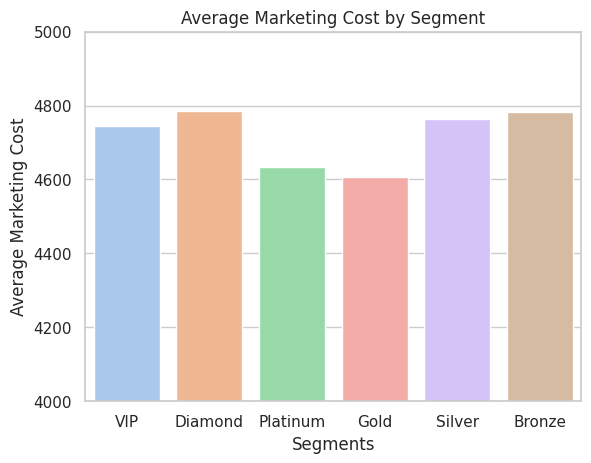

In [ ]:
VIP_총마케팅비용_mean = VIP['총마케팅비용'].mean()
Diamond_총마케팅비용_mean = Diamond['총마케팅비용'].mean()
Platinum_총마케팅비용_mean = Platinum['총마케팅비용'].mean()
Gold_총마케팅비용_mean = Gold['총마케팅비용'].mean()
Silver_총마케팅비용_mean = Silver['총마케팅비용'].mean()
Bronze_총마케팅비용_mean = Bronze['총마케팅비용'].mean()

print("VIP 총마케팅비용 평균값:", VIP_총마케팅비용_mean)
print("Diamond 총마케팅비용 평균값:", Diamond_총마케팅비용_mean)
print("Platinum 총마케팅비용 평균값:", Platinum_총마케팅비용_mean)
print("Gold 총마케팅비용 평균값:", Gold_총마케팅비용_mean)
print("Silver 총마케팅비용 평균값:", Silver_총마케팅비용_mean)
print("Bronze 총마케팅비용 평균값:", Bronze_총마케팅비용_mean)

segment_means = [VIP_총마케팅비용_mean, Diamond_총마케팅비용_mean, Platinum_총마케팅비용_mean, Gold_총마케팅비용_mean, Silver_총마케팅비용_mean, Bronze_총마케팅비용_mean]

segments = ['VIP', 'Diamond', 'Platinum', 'Gold', 'Silver', 'Bronze']
sns.set_style("whitegrid")
sns.barplot(x=segments, y=segment_means, palette="pastel")

plt.title('Average Marketing Cost by Segment')
plt.xlabel('Segments')
plt.ylabel('Average Marketing Cost')
plt.ylim(4000, 5000)
plt.show()

* 세그먼트 별로 마케팅 비용의 큰 차이는 없지만, 그 중에서도 마케팅 비용이 높은 날짜에 많이 구매한 세그먼트는 Platinum과 Bronze이 있다.
* 이 결과로 마케팅 비용을 높혔을 때 효과를 많이 받는 세그먼트는 Platinum과 Bronze이라고 생각해볼 수 있으며, Platinum과 Bronze의 전환율을 높히기 위해서 마케팅을 활용해볼 수 있다.

2. 각 세그먼트 별로 마케팅 비용과 ARPPU의 상관관계 확인

상관관계가 높다면 마케팅 비용을 높혔을 때 ARPPU가 높아지는 것이기 때문에 ARPPU와 마케팅비용간의 피어슨 상관계수를 확인해보았다.


In [ ]:
from scipy.stats import pearsonr
# 피어슨 상관계수 계산
correlation_VIP, _ = pearsonr(VIP_mar['ARPPU'], VIP_mar['총마케팅비용'])
correlation_Diamond, _ = pearsonr(Diamond_mar['ARPPU'], Diamond_mar['총마케팅비용'])
correlation_Platinum, _ = pearsonr(Platinum_mar['ARPPU'], Platinum_mar['총마케팅비용'])
correlation_Gold, _ = pearsonr(Gold_mar['ARPPU'], Gold_mar['총마케팅비용'])
correlation_Silver, _ = pearsonr(Silver_mar['ARPPU'], Silver_mar['총마케팅비용'])
correlation_Bronze, _ = pearsonr(Bronze_mar['ARPPU'], Bronze_mar['총마케팅비용'])

print("VIP 세그먼트의 피어슨 상관계수:", correlation_VIP)
print("Diamond 세그먼트의 피어슨 상관계수:", correlation_Diamond)
print("Platinum 세그먼트의 피어슨 상관계수:", correlation_Platinum)
print("Gold 세그먼트의 피어슨 상관계수:", correlation_Gold)
print("Silver 세그먼트의 피어슨 상관계수:", correlation_Silver)
print("Bronze 세그먼트의 피어슨 상관계수:", correlation_Bronze)

VIP 세그먼트의 피어슨 상관계수: 0.23917566134923118
Diamond 세그먼트의 피어슨 상관계수: 0.17594733633097567
Platinum 세그먼트의 피어슨 상관계수: 0.20972564632349375
Gold 세그먼트의 피어슨 상관계수: 0.17797220256535493
Silver 세그먼트의 피어슨 상관계수: 0.08567914739206621
Bronze 세그먼트의 피어슨 상관계수: 0.2114783021036862


* VIP와 Diamond, Bronze의 경우 어느정 마케팅비용이 ARPPU와 상관관계가 있다고 볼 수 있으며,나머지 세그먼트도 약한 상관관계는 가지고 있다.
* 따라서 세그먼트 VIP와 Diamond, Bronze의 경우 마케팅 비용이 높아지면 사용자당 평균 매출이 증가하고, 매출 증대를 위해 마케팅을 전략적으로 활용가능해 볼 수 있다.

3. 온/오프라인 마케팅 비용의 ARPPU와의 상관관계

>각 세그먼트 별로 온라인 마케팅과 오프라인 마케팅 중 어느 마케팅을 사용했을 때 매출증대에 효과가 있는 파악하기 위해 각각 나누어서 상관계수를 확인헤보았다.

<Axes: >

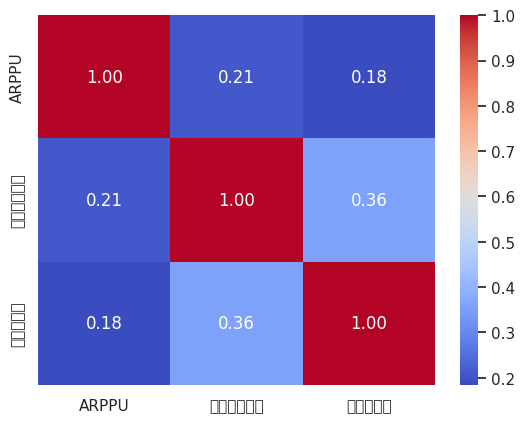

In [ ]:
VIP_mar_subset = VIP_mar[['ARPPU', '오프라인비용', '온라인비용']]
sns.heatmap(VIP_mar_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
Diamond_mar_subset = Diamond_mar[['ARPPU', '오프라인비용', '온라인비용']]
sns.heatmap(VIP_mar_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
Platinum_mar_subset = Platinum_mar[['ARPPU', '오프라인비용', '온라인비용']]
sns.heatmap(Platinum_mar_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
Gold_mar_subset = Gold_mar[['ARPPU', '오프라인비용', '온라인비용']]
sns.heatmap(Gold_mar_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
Silver_mar_subset = Silver_mar[['ARPPU', '오프라인비용', '온라인비용']]
sns.heatmap(Silver_mar_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [ ]:
Bronze_mar_subset = Bronze_mar[['ARPPU', '오프라인비용', '온라인비용']]
sns.heatmap(Bronze_mar_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")

* VIP의 경우 오프라인 비용과 ARPU와의 상관관계가 온라인보다 조금 높았으며, 오프라인 온라인 둘 다 상관관계가0.2 부근으로 큰 차이가 있지는 않았다.
* Diamond의 경우 온라인은 0.08, 오프라인은 0.22로 오프라인 마케팅 비용을 높히는 것이 매출증대에 효과가 크다는 것을 알 수 있다.
* Bronze의 경우 온라인과의 상관관계는 0.24 오프라인과의 상관관계는 0.10으로 온라인이 앞도적으로 높았기 때문에 Bronze를 위한 마케팅 전략을 펼칠 때에는 온라인 비용을 높히는 것이 훨씬 효율적이라는 것을 알 수 있었다.

#### 정리

  **VIP, Diamond : 매출증대를 위해서 오프라인 마케팅 비용 증가가 효과적**

  **Platinum : 전환율을 높히기 위해서 마케팅 비용 증가가 효과적**

 **Bronze : 매출증대를 위해서 온라인 마케팅 비용 증가가 효과적**



3-4-2) 재구매 유도를 위한 마케팅 주기 결정

마케팅 주기 결정을 위해 클러스터별 재구매까지 걸리는 평균 날짜를 구해보았다.\
(당일 구매한 이력이 여러 개 있을 때는 재구매로 계산하지 않고, 다른 날짜에 구매한 내력이 있는 것만 재구매로 계산)

 (Onlinesales_info분석에서 생성한 파생변수 `재구매날까지의일`사용)



In [ ]:
# 각 세그먼트별로 0인 경우 같은 날 구매이력이 있는 경우 0으로 추가해두었기 때문에
# 같은 날에 구매한 값을 제외하기 위해서 0 을 제외한 평균을 구했다.
VIP_no_zero = VIP[VIP['재구매날까지의일'] != 0]
Diamond_no_zero = Diamond[Diamond['재구매날까지의일'] != 0]
Platinum_no_zero = Platinum[Platinum['재구매날까지의일'] != 0]
Gold_no_zero = Gold[Gold['재구매날까지의일'] != 0]
Silver_no_zero = Silver[Silver['재구매날까지의일'] != 0]
Bronze_no_zero = Bronze[Bronze['재구매날까지의일'] != 0]

# 각 세그먼트별로 0을 제외한 값들의 평균 계산
mean_VIP = VIP_no_zero['재구매날까지의일'].mean()
mean_Diamond = Diamond_no_zero['재구매날까지의일'].mean()
mean_Platinum = Platinum_no_zero['재구매날까지의일'].mean()
mean_Gold = Gold_no_zero['재구매날까지의일'].mean()
mean_Silver = Silver_no_zero['재구매날까지의일'].mean()
mean_Bronze = Bronze_no_zero['재구매날까지의일'].mean()

print('VIP가 재구매까지 걸리는 기간: ', mean_VIP)
print('Diamond가 재구매까지 걸리는 기간: ', mean_Diamond)
print('Platinum가 재구매까지 걸리는 기간: ', mean_Platinum)
print('Gold가 재구매까지 걸리는 기간: ', mean_Gold)
print('Silver가 재구매까지 걸리는 기간: ', mean_Silver)
print('Bronze가 재구매까지 걸리는 기간: ', mean_Bronze)

VIP가 재구매까지 걸리는 기간:  40.663636363636364
Diamond가 재구매까지 걸리는 기간:  62.355437665782496
Platinum가 재구매까지 걸리는 기간:  58.48148148148148
Gold가 재구매까지 걸리는 기간:  62.28502415458937
Silver가 재구매까지 걸리는 기간:  73.22413793103448
Bronze가 재구매까지 걸리는 기간:  67.82142857142857


3-4-3) 마케팅 요일 결정

> 세그먼트 별로 많이 구매하는 요일이 다를거라 생각하여 세그먼트 별 구매횟수가 많은 요일을 구해보았다.

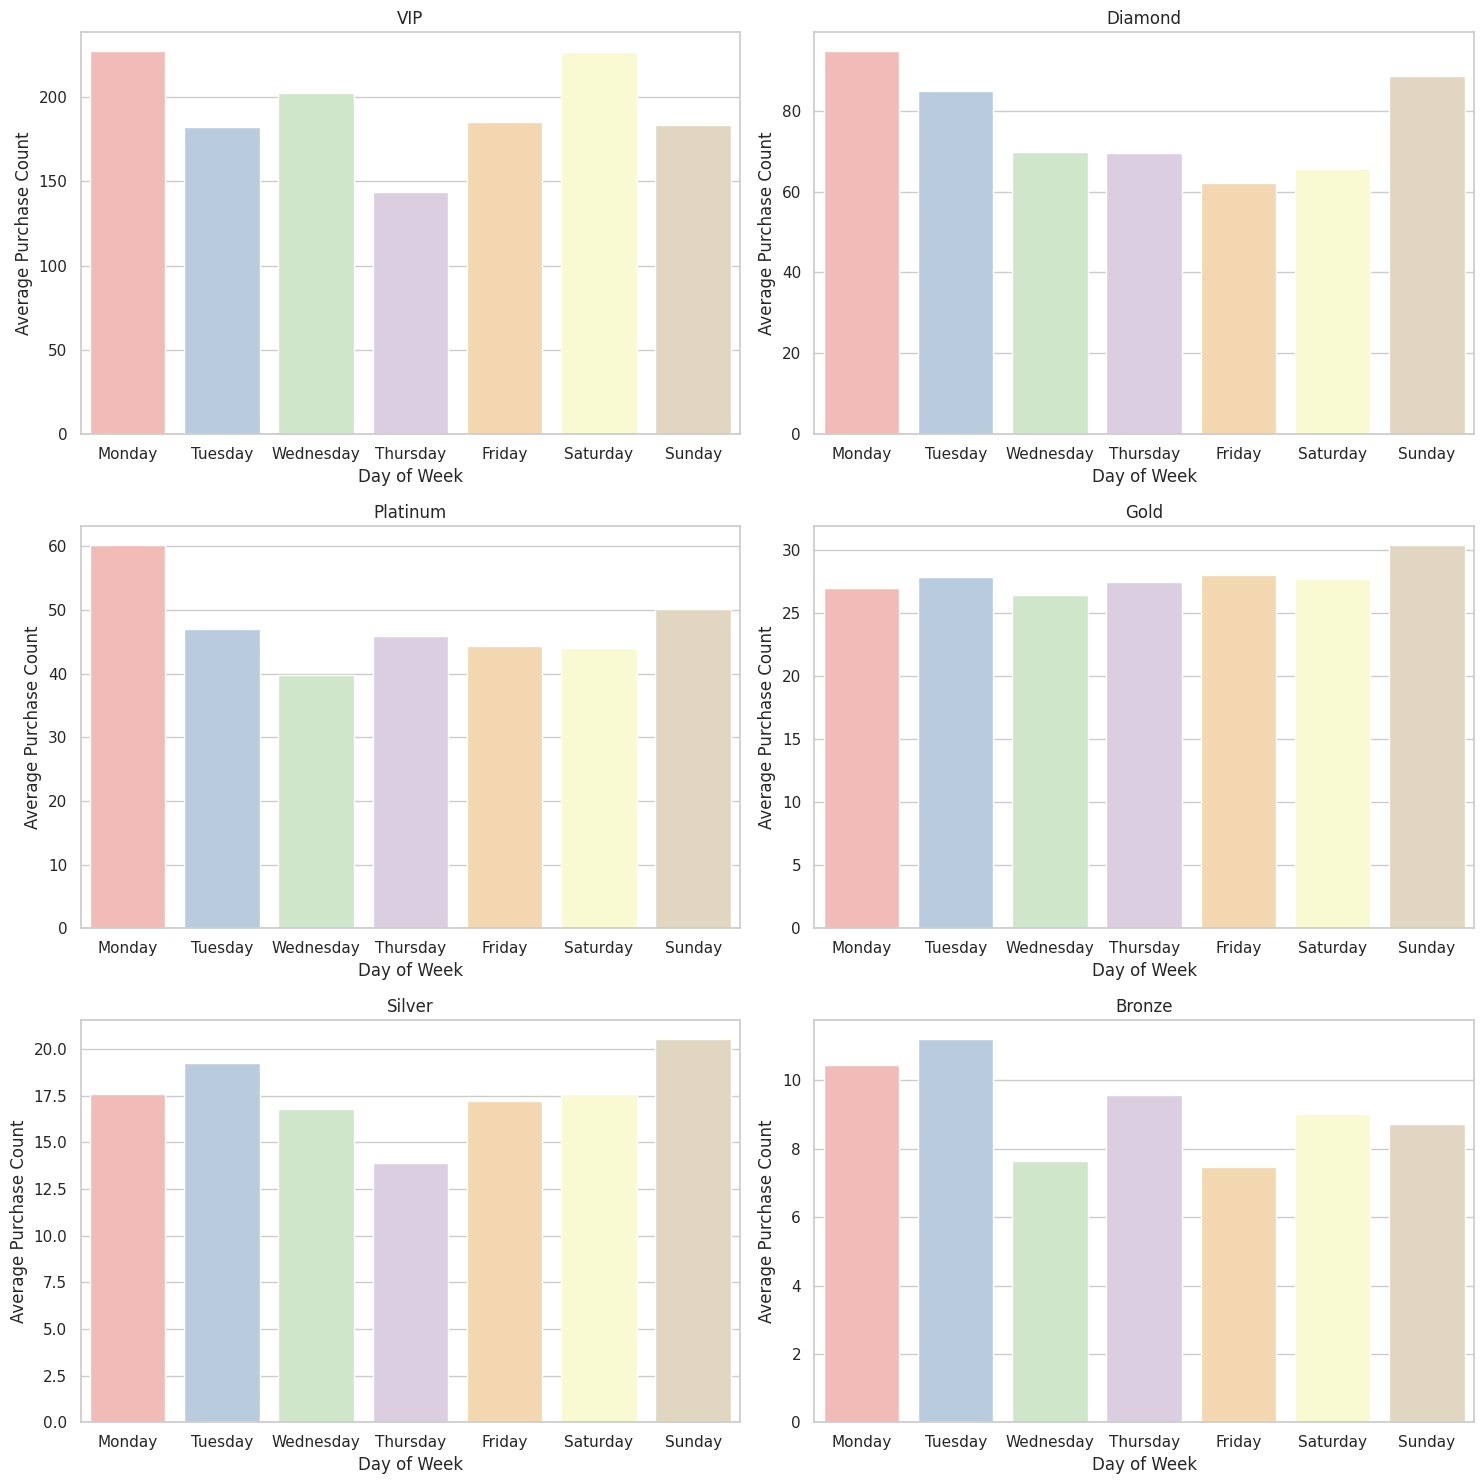

In [ ]:
VIP['요일'] = VIP['거래날짜'].dt.day_name()
Diamond['요일'] = Diamond['거래날짜'].dt.day_name()
Platinum['요일'] = Platinum['거래날짜'].dt.day_name()
Gold['요일'] = Gold['거래날짜'].dt.day_name()
Silver['요일'] = Silver['거래날짜'].dt.day_name()
Bronze['요일'] = Bronze['거래날짜'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

VIP_day = VIP.groupby('요일').agg({'구매횟수': 'mean'}).reset_index()
Diamond_day = Diamond.groupby('요일').agg({'구매횟수': 'mean'}).reset_index()
Platinum_day = Platinum.groupby('요일').agg({'구매횟수': 'mean'}).reset_index()
Gold_day = Gold.groupby('요일').agg({'구매횟수': 'mean'}).reset_index()
Silver_day = Silver.groupby('요일').agg({'구매횟수': 'mean'}).reset_index()
Bronze_day = Bronze.groupby('요일').agg({'구매횟수': 'mean'}).reset_index()

plt.figure(figsize=(15, 15))

plt.subplot(3, 2, 1)
sns.barplot(x='요일', y='구매횟수', data=VIP_day, order=day_order, palette='Pastel1')
plt.title('VIP')
plt.xlabel('Day of Week')
plt.ylabel('Average Purchase Count')

plt.subplot(3, 2, 2)
sns.barplot(x='요일', y='구매횟수', data=Diamond_day, order=day_order, palette='Pastel1')
plt.title('Diamond')
plt.xlabel('Day of Week')
plt.ylabel('Average Purchase Count')

plt.subplot(3, 2, 3)
sns.barplot(x='요일', y='구매횟수', data=Platinum_day, order=day_order, palette='Pastel1')
plt.title('Platinum')
plt.xlabel('Day of Week')
plt.ylabel('Average Purchase Count')

plt.subplot(3, 2, 4)
sns.barplot(x='요일', y='구매횟수', data=Gold_day, order=day_order, palette='Pastel1')
plt.title('Gold')
plt.xlabel('Day of Week')
plt.ylabel('Average Purchase Count')

plt.subplot(3, 2, 5)
sns.barplot(x='요일', y='구매횟수', data=Silver_day, order=day_order, palette='Pastel1')
plt.title('Silver')
plt.xlabel('Day of Week')
plt.ylabel('Average Purchase Count')

plt.subplot(3, 2, 6)
sns.barplot(x='요일', y='구매횟수', data=Bronze_day, order=day_order, palette='Pastel1')
plt.title('Bronze')
plt.xlabel('Day of Week')
plt.ylabel('Average Purchase Count')

plt.tight_layout()
plt.show()

> 정리

**VIP 세그먼트:** 토요일

**Diamond 세그먼트:** : 일요일

**Platinum 세그먼트:** :일요일

**Gold 세그먼트:** : 월요일

**Silver 세그먼트:** : 일요일

**Bronze 세그먼트:** : 화요일

### 3-5) 쿠폰을 제공하는 상황 / 제공할 쿠폰

>쿠폰 제공 방안 정리

**VIP 세그먼트:**

**Diamond 세그먼트:**

**Platinum 세그먼트:**

**Gold 세그먼트:**

**Silver 세그먼트:**

**Bronze 세그먼트:**

쿠폰을 제공할 품목 : 클러스터별 추천해줘야 하는 제품을 기반으로 제공

품목 별 많이 이용한 할인율 : 추천해줘야 하는 제품이 해당하는 금액()에 맞는 할인율 제공 (금액별로 사용하는 비율 차이 )


쿠폰을 제공하는 달이 다름 → 10% (1,4,7,10) , 20% (2,5,8,11), 30% (3,6,9,12) -> 기존의 쿠폰 제공 방식이 비효율적이였다는 면을 지적하면서, 유동적인 쿠폰 제공 서비스를 유도

# 4.클러스터 별 솔루션 제공

### **4-1) VIP**

#### **크로스 셀링**
VIP / DIamond에게는 이미 거래했던 카테고리 개수보다 더 많은 카테고리 수를 이용할 수 있게끔 해당 고객이 구매한 카테고리를 바탕으로 다른 카테고리의 제품을 추천해주는 크로스셀링 진행하기로 하였다.

고객별로 추천해줄 카테고리의 제품을 구하는 방법

final_recommend(df,user_id) , df에는 해당 클러스터(1)의 df, user_id는 고객의 user_id를 넣어서 사용하면 된다.

#### **쿠폰 제공**
해당 고객의 거래 카테고리 개수를 늘리기 위하여, 추천 받은 카테고리의 제품에게 할인쿠폰 제공한다.



#### **마케팅 전략**
  * 재구매 기간을 고려하여 45일의 텀을 두고 마케팅을 진행하는 것이 좋으며,
  가장 구매횟수가 많은 토요일을 위주로 마케팅을 진행하는 것이 효과적이다.
  * VIP 세그먼트는 오프라인 마케팅 비용을 높였을 때 효과적이므로, 매출을 증대하기 위해서는 오프라인 마케팅 비용을 높여서 진행해야 한다.



### **4-2) Diamond**

#### **크로스 셀링**
VIP / DIamond에게는 이미 거래했던 카테고리 개수보다 더 많은 카테고리 수를 이용할 수 있게끔 해당 고객이 구매한 카테고리를 바탕으로 다른 카테고리의 제품을 추천해주는 크로스셀링 진행하기로 하였다.

고객별로 추천해줄 카테고리의 제품을 구하는 방법

final_recommend(df,user_id) , df에는 해당 클러스터(2)의 df, user_id는 고객의 user_id를 넣어서 사용하면 된다.

#### **쿠폰 제공**

#### **마케팅 전략**
  * 재구매 기간을 고려하여 55일의 텀을 두고 마케팅을 진행하는 것이 바람직하며,
  가장 구매횟수가 많은 일요일 주목하여 마케팅 전략을 구성하는 것이 효율적일 것이다.
  * Diamond 또한 VIP 세그먼트와 같이 오프라인 마케팅 비용을 높였을 때 효과적이므로, 매출을 증대하기 위해서는 오프라인 마케팅 비용을 높여서 진행해야 한다.



### **4-3) Platinum**

#### **묶음 상품 판매**

Product_0185와 Product_0184의 묶음 상품

Product_0904와 Product_0185의 묶음 상품

Product_0894와 Product_0880의 묶음 상품

Product_0916와 Product_0915의 묶음 상품

Product_0915와 Product_0917의 묶음 상품

Product_0915와 Product_0918의 묶음 상품

Product_0916와 Product_0917의 묶음 상품

Product_0916와 Product_0918의 묶음 상품

Product_0918와 Product_0917의 묶음 상품.

#### **쿠폰 제공**

#### **마케팅 전략**

  * 마찬가지로 재구매 기간을 고려하여 69일의 텀을 두고 마케팅을 실행하는 것이 좋으며, 구매횟수가 많은 일요일을 기반으로 마케팅 활동을 계획하면 전략의 효과를 극대화할 수 있다.
  * Platinum 세그먼트는 전환율을 높히기 위해서 전체적인 마케팅 비용을 높여서 진행하는 것이 좋다.

### **4-4) Gold**

#### **묶음 상품 판매** .
Product_0847와 Product_0848의 묶음 상품

Product_0904와 Product_0854의 묶음 상품

Product_0894와 Product_0880의 묶음 상품

Product_0904와 Product_0900의 묶음 상품

Product_0904와 Product_0905의 묶음 상품

Product_0904와 Product_0907의 묶음 상품

Product_0969와 Product_0907의 묶음 상품

Product_0916와 Product_0915의 묶음 상품

Product_0915와 Product_0917의 묶음 상품

Product_0915와 Product_0918의 묶음 상품

Product_0916와 Product_0917의 묶음 상품

Product_0916와 Product_0918의 묶음 상품

Product_0918와 Product_0917의 묶음 상품

Product_0951와 Product_0944의 묶음 상품
#### **쿠폰 제공**

#### **마케팅 전략**
  * 재구매 주기를 고려하여 61일의 간격으로 마케팅을 진행하는 것이 좋으며, 월요일에 구매가 집중되므로 이를 기준으로 마케팅 전략을 구성하는 것이 효과적이다.

### **4-5) Silver**

#### **크로스 셀링** .

#### **쿠폰 제공**

#### **마케팅 전략**
 * 63일의 텀을 두고 마케팅을 계획하는 것이 적절하며,일요일에 구매 횟수가 많으므로 해당 요일을 중심으로 마케팅 활동을 진행할 필요가 있다.

### **4_6)  Bronze**

#### **크로스 셀링** .

#### **쿠폰 제공**

#### **마케팅 전략**
* 재구매 주기를 고려하여 83일의 간격으로 마케팅을 진행하는 것이 유용하며,
  화요일에 가장 많은 구매가 이루어지므로 이를 중심으로 마케팅 전략을 구성하는 것이 효과적이다.
  * Bronze 세그먼트는 온라인 마케팅 비용을 높였을 때 효과적이므로, 매출을 증대하기 위해서는 온라인 마케팅 비용을 높여서 진행해야 한다.